# Customer Segment Unsupervised

### Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### Load the Dataset

In [2]:
# Load the customer dataset
# Use latin1 so City values like São Paulo are read correctly
df = pd.read_csv(
    r"C:\Users\maram\OneDrive\Desktop\Team task-1\customer_data.csv",
    encoding="latin1"
)

In [3]:
# Display the first 5 rows
df.head()

,Customer_ID,Birth_Year,Education_Level,Marital_Status,Annual_Income,Kids_Home,Teens_Home,Customer_Since,Last_Purchase_Recency,Spent_Wine,...,Mobile_App_User,Email_Subscriber,Device_Type,Referred_By_Friend,Social_Media_User,Membership_Tier,Total_Amount_Spent,Customer_Age,Family_Size,Senior_Citizen
0,1,1978,Graduation,Widow,40175.23,1,1,26-09-2010,68,440,...,1,0,Desktop,1,1,Silver,1265,47,2,0
1,2,1991,PhD,Widow,27979.68,0,1,03-11-2012,99,826,...,1,1,Desktop,1,0,Basic,1647,34,1,0
2,3,1968,PhD,Married,64747.68,0,0,31-10-2013,63,895,...,0,0,Desktop,0,1,Silver,1806,57,1,0
3,4,1954,Graduation,Widow,50185.85,2,2,30-04-2010,65,127,...,0,1,Mobile,0,1,Basic,1207,71,4,1
4,5,1982,Graduation,Married,53163.09,1,2,25-09-2015,49,140,...,0,1,Mobile,1,1,Basic,934,43,4,0


### Fix City Encoding

In [4]:
# Fix any mangled São Paulo spellings that may appear from encoding issues
df['City'] = df['City'].replace({
    'SÃ£o Paulo': 'São Paulo',
    'S�o Paulo': 'São Paulo'
})

# Confirm cleaned City values
df['City'].value_counts()

City
New York     2097
London       1998
São Paulo    1986
Berlin       1985
Mumbai       1934
Name: count, dtype: int64

### Inspect the Dataset

In [5]:
# Display the number of rows and columns
df.shape

(10000, 42)

In [6]:
# Check the data type of every column
df.dtypes

Customer_ID                int64
Birth_Year                 int64
Education_Level              str
Marital_Status               str
Annual_Income            float64
Kids_Home                  int64
Teens_Home                 int64
Customer_Since               str
Last_Purchase_Recency      int64
Spent_Wine                 int64
Spent_Fruits               int64
Spent_Meat                 int64
Spent_Fish                 int64
Spent_Sweets               int64
Spent_Gold                 int64
Deals_Purchased            int64
Web_Purchases              int64
Catalog_Purchases          int64
Store_Purchases            int64
Monthly_Web_Visits         int64
Campaign1_Accepted         int64
Campaign2_Accepted         int64
Campaign3_Accepted         int64
Campaign4_Accepted         int64
Campaign5_Accepted         int64
Filed_Complaint            int64
Contact_Cost               int64
Revenue_Contribution       int64
Campaign_Response          int64
Country                      str
City      

In [7]:
# Display dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 42 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer_ID            10000 non-null  int64  
 1   Birth_Year             10000 non-null  int64  
 2   Education_Level        10000 non-null  str    
 3   Marital_Status         10000 non-null  str    
 4   Annual_Income          10000 non-null  float64
 5   Kids_Home              10000 non-null  int64  
 6   Teens_Home             10000 non-null  int64  
 7   Customer_Since         10000 non-null  str    
 8   Last_Purchase_Recency  10000 non-null  int64  
 9   Spent_Wine             10000 non-null  int64  
 10  Spent_Fruits           10000 non-null  int64  
 11  Spent_Meat             10000 non-null  int64  
 12  Spent_Fish             10000 non-null  int64  
 13  Spent_Sweets           10000 non-null  int64  
 14  Spent_Gold             10000 non-null  int64  
 15  Deals_Purchase

### Missing Values

In [8]:
# Count missing values in every column
df.isnull().sum()

Customer_ID              0
Birth_Year               0
Education_Level          0
Marital_Status           0
Annual_Income            0
Kids_Home                0
Teens_Home               0
Customer_Since           0
Last_Purchase_Recency    0
Spent_Wine               0
Spent_Fruits             0
Spent_Meat               0
Spent_Fish               0
Spent_Sweets             0
Spent_Gold               0
Deals_Purchased          0
Web_Purchases            0
Catalog_Purchases        0
Store_Purchases          0
Monthly_Web_Visits       0
Campaign1_Accepted       0
Campaign2_Accepted       0
Campaign3_Accepted       0
Campaign4_Accepted       0
Campaign5_Accepted       0
Filed_Complaint          0
Contact_Cost             0
Revenue_Contribution     0
Campaign_Response        0
Country                  0
City                     0
Region_Code              0
Mobile_App_User          0
Email_Subscriber         0
Device_Type              0
Referred_By_Friend       0
Social_Media_User        0
M

### Unique Values

In [9]:
# Find the number of unique values in each column
df.nunique().sort_values()

Revenue_Contribution         1
Contact_Cost                 1
Campaign1_Accepted           2
Campaign2_Accepted           2
Campaign3_Accepted           2
Campaign4_Accepted           2
Filed_Complaint              2
Campaign5_Accepted           2
Campaign_Response            2
Referred_By_Friend           2
Email_Subscriber             2
Senior_Citizen               2
Social_Media_User            2
Mobile_App_User              2
Kids_Home                    3
Teens_Home                   3
Device_Type                  3
Membership_Tier              4
Education_Level              4
Country                      5
Marital_Status               5
City                         5
Family_Size                  6
Deals_Purchased             10
Store_Purchases             10
Web_Purchases               10
Catalog_Purchases           10
Monthly_Web_Visits          20
Birth_Year                  62
Customer_Age                62
Spent_Fruits               100
Last_Purchase_Recency      100
Spent_Sw

In [10]:
df

,Customer_ID,Birth_Year,Education_Level,Marital_Status,Annual_Income,Kids_Home,Teens_Home,Customer_Since,Last_Purchase_Recency,Spent_Wine,...,Mobile_App_User,Email_Subscriber,Device_Type,Referred_By_Friend,Social_Media_User,Membership_Tier,Total_Amount_Spent,Customer_Age,Family_Size,Senior_Citizen
0,1,1978,Graduation,Widow,40175.23,1,1,26-09-2010,68,440,...,1,0,Desktop,1,1,Silver,1265,47,2,0
1,2,1991,PhD,Widow,27979.68,0,1,03-11-2012,99,826,...,1,1,Desktop,1,0,Basic,1647,34,1,0
2,3,1968,PhD,Married,64747.68,0,0,31-10-2013,63,895,...,0,0,Desktop,0,1,Silver,1806,57,1,0
3,4,1954,Graduation,Widow,50185.85,2,2,30-04-2010,65,127,...,0,1,Mobile,0,1,Basic,1207,71,4,1
4,5,1982,Graduation,Married,53163.09,1,2,25-09-2015,49,140,...,0,1,Mobile,1,1,Basic,934,43,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,1960,Graduation,Widow,70401.68,2,0,22-02-2010,94,851,...,0,0,Tablet,1,1,Silver,1511,65,2,1
9996,9997,1945,Graduation,Divorced,66580.08,2,0,24-11-2010,0,73,...,0,1,Mobile,1,0,Silver,957,80,2,1
9997,9998,1940,Graduation,Widow,25768.75,0,2,01-10-2011,73,209,...,1,1,Mobile,0,0,Silver,908,85,2,1
9998,9999,1943,Graduation,Together,38167.35,2,2,23-05-2014,17,224,...,1,0,Desktop,1,0,Gold,678,82,5,1


### Numerical and Categorical Columns

In [11]:
# Select only numerical columns
numerical_columns = df.select_dtypes(include=np.number).columns

numerical_columns

Index(['Customer_ID', 'Birth_Year', 'Annual_Income', 'Kids_Home', 'Teens_Home',
       'Last_Purchase_Recency', 'Spent_Wine', 'Spent_Fruits', 'Spent_Meat',
       'Spent_Fish', 'Spent_Sweets', 'Spent_Gold', 'Deals_Purchased',
       'Web_Purchases', 'Catalog_Purchases', 'Store_Purchases',
       'Monthly_Web_Visits', 'Campaign1_Accepted', 'Campaign2_Accepted',
       'Campaign3_Accepted', 'Campaign4_Accepted', 'Campaign5_Accepted',
       'Filed_Complaint', 'Contact_Cost', 'Revenue_Contribution',
       'Campaign_Response', 'Region_Code', 'Mobile_App_User',
       'Email_Subscriber', 'Referred_By_Friend', 'Social_Media_User',
       'Total_Amount_Spent', 'Customer_Age', 'Family_Size', 'Senior_Citizen'],
      dtype='str')

In [12]:
# Select columns that are not numerical
categorical_columns = df.select_dtypes(exclude=np.number).columns

categorical_columns

Index(['Education_Level', 'Marital_Status', 'Customer_Since', 'Country',
       'City', 'Device_Type', 'Membership_Tier'],
      dtype='str')

### Value Counts

In [13]:
df['Marital_Status'].value_counts()

Marital_Status
Widow       2079
Divorced    2061
Single      1976
Married     1947
Together    1937
Name: count, dtype: int64

In [14]:
df['Country'].value_counts()

Country
Brazil     2102
Germany    2047
India      1960
UK         1956
USA        1935
Name: count, dtype: int64

In [15]:
df['City'].value_counts()

City
New York     2097
London       1998
São Paulo    1986
Berlin       1985
Mumbai       1934
Name: count, dtype: int64

In [16]:
df['Device_Type'].value_counts()

Device_Type
Mobile     4926
Desktop    4091
Tablet      983
Name: count, dtype: int64

In [17]:
df['Membership_Tier'].value_counts()

Membership_Tier
Basic       4003
Silver      2978
Gold        2006
Platinum    1013
Name: count, dtype: int64

### Find Negative Values

In [18]:
# Select numerical columns
numeric_data = df.select_dtypes(include=np.number)

negative_values = (numeric_data < 0).sum()

negative_values[negative_values > 0]

Annual_Income    5
dtype: int64

### Find Invalid Binary Values

In [19]:
# List of columns that should contain only 0 and 1
binary_columns = [
    'Campaign1_Accepted',
    'Campaign2_Accepted',
    'Campaign3_Accepted',
    'Campaign4_Accepted',
    'Campaign5_Accepted',
    'Filed_Complaint',
    'Campaign_Response',
    'Mobile_App_User',
    'Email_Subscriber',
    'Referred_By_Friend',
    'Social_Media_User',
    'Senior_Citizen'
]

df[binary_columns].apply(lambda x: x.unique())

,Campaign1_Accepted,Campaign2_Accepted,Campaign3_Accepted,Campaign4_Accepted,Campaign5_Accepted,Filed_Complaint,Campaign_Response,Mobile_App_User,Email_Subscriber,Referred_By_Friend,Social_Media_User,Senior_Citizen
0,1,1,0,1,0,0,1,1,0,1,1,0
1,0,0,1,0,1,1,0,0,1,0,0,1


### Find Invalid Age Values

In [20]:
# Check the minimum and maximum customer age
df['Customer_Age'].agg(['min', 'max'])

min    24
max    85
Name: Customer_Age, dtype: int64

### Find Invalid Birth Years

In [21]:
# Check the minimum and maximum birth year
df['Birth_Year'].agg(['min', 'max'])

min    1940
max    2001
Name: Birth_Year, dtype: int64

### Fix Negative Annual Income

In [22]:
# Replace negative Annual Income values with NaN
df.loc[df['Annual_Income'] < 0, 'Annual_Income'] = np.nan

df['Annual_Income'] = df['Annual_Income'].fillna(
    df['Annual_Income'].median()
)

df['Annual_Income'].min()

np.float64(566.58)

### Check Again for Negative Values

In [23]:
# Check whether any negative numerical values remain
negative_values = (df.select_dtypes(include=np.number) < 0).sum()

negative_values[negative_values > 0]

Series([], dtype: int64)

### Convert Customer_Since

In [24]:
# Convert Customer_Since from text into datetime format
df['Customer_Since'] = pd.to_datetime(
    df['Customer_Since'],
    dayfirst=True,
    errors='coerce'
)
df['Customer_Since'].head()

0   2010-09-26
1   2012-11-03
2   2013-10-31
3   2010-04-30
4   2015-09-25
Name: Customer_Since, dtype: datetime64[us]

### Check Invalid Dates

In [25]:
# Check whether any Customer_Since values could not be converted
df['Customer_Since'].isnull().sum()

np.int64(0)

In [26]:
# Check missing values in every column

missing_values = df.isnull().sum()

# Display only columns that contain missing values
missing_values[missing_values > 0]

Series([], dtype: int64)

### Create Useful Date Features

In [27]:
# Extract the year when the customer joined
df['Customer_Since_Year'] = df['Customer_Since'].dt.year

# Extract the month when the customer joined
df['Customer_Since_Month'] = df['Customer_Since'].dt.month

# Display the new columns
df[['Customer_Since', 'Customer_Since_Year', 'Customer_Since_Month']].head()

,Customer_Since,Customer_Since_Year,Customer_Since_Month
0,2010-09-26,2010,9
1,2012-11-03,2012,11
2,2013-10-31,2013,10
3,2010-04-30,2010,4
4,2015-09-25,2015,9


### Correlation

In [28]:
# Select numerical columns
numeric_data = df.select_dtypes(include=np.number)
correlation_matrix = numeric_data.corr()

correlation_matrix

,Customer_ID,Birth_Year,Annual_Income,Kids_Home,Teens_Home,Last_Purchase_Recency,Spent_Wine,Spent_Fruits,Spent_Meat,Spent_Fish,...,Mobile_App_User,Email_Subscriber,Referred_By_Friend,Social_Media_User,Total_Amount_Spent,Customer_Age,Family_Size,Senior_Citizen,Customer_Since_Year,Customer_Since_Month
Customer_ID,1.000000,-0.006577,0.001194,0.001275,0.000275,-0.012494,-0.007079,0.018814,0.020169,0.007886,...,0.019374,0.003643,0.013452,0.010033,0.011250,0.006577,-0.009306,0.016226,-0.006340,-0.009790
Birth_Year,-0.006577,1.000000,0.022903,-0.000877,-0.005570,0.006893,0.021062,-0.003236,0.000650,-0.001602,...,-0.014503,-0.009834,-0.001268,0.006281,0.013299,-1.000000,-0.004200,-0.847354,0.010557,0.018596
Annual_Income,0.001194,0.022903,1.000000,0.003054,-0.015791,-0.009082,-0.008636,0.016779,0.000257,-0.005379,...,-0.007025,0.004925,0.002400,-0.007825,-0.001478,-0.022903,-0.008822,-0.025141,0.001082,0.002062
Kids_Home,0.001275,-0.000877,0.003054,1.000000,-0.006942,-0.009003,0.005083,0.016337,0.007381,-0.014976,...,0.007171,0.018043,0.009926,0.000126,0.005724,0.000877,0.651928,0.000454,-0.014814,0.005740
Teens_Home,0.000275,-0.005570,-0.015791,-0.006942,1.000000,-0.004861,-0.000054,0.005167,0.005565,-0.009722,...,0.000702,-0.012099,0.002688,-0.003789,0.003133,0.005570,0.645584,0.009485,-0.001519,0.003609
Last_Purchase_Recency,-0.012494,0.006893,-0.009082,-0.009003,-0.004861,1.000000,-0.009238,0.010584,-0.010348,0.000629,...,0.009946,0.017530,-0.008106,0.005622,-0.016437,-0.006893,-0.006599,-0.009889,0.001843,0.011164
Spent_Wine,-0.007079,0.021062,-0.008636,0.005083,-0.000054,-0.009238,1.000000,-0.007616,-0.001876,0.004987,...,-0.013092,0.012303,-0.002863,0.019304,0.701638,-0.021062,0.003886,-0.023714,0.000927,0.000316
Spent_Fruits,0.018814,-0.003236,0.016779,0.016337,0.005167,0.010584,-0.007616,1.000000,0.001594,-0.008842,...,0.007865,-0.000241,0.000521,0.001024,0.064872,0.003236,0.013454,-0.000078,-0.005442,0.011589
Spent_Meat,0.020169,0.000650,0.000257,0.007381,0.005565,-0.010348,-0.001876,0.001594,1.000000,-0.016377,...,0.014896,-0.000158,-0.002514,0.000932,0.557522,-0.000650,0.003104,0.002136,0.004907,-0.004014
Spent_Fish,0.007886,-0.001602,-0.005379,-0.014976,-0.009722,0.000629,0.004987,-0.008842,-0.016377,1.000000,...,0.001025,-0.017459,0.006092,0.001640,0.212317,0.001602,-0.015826,0.008963,-0.014701,0.011554


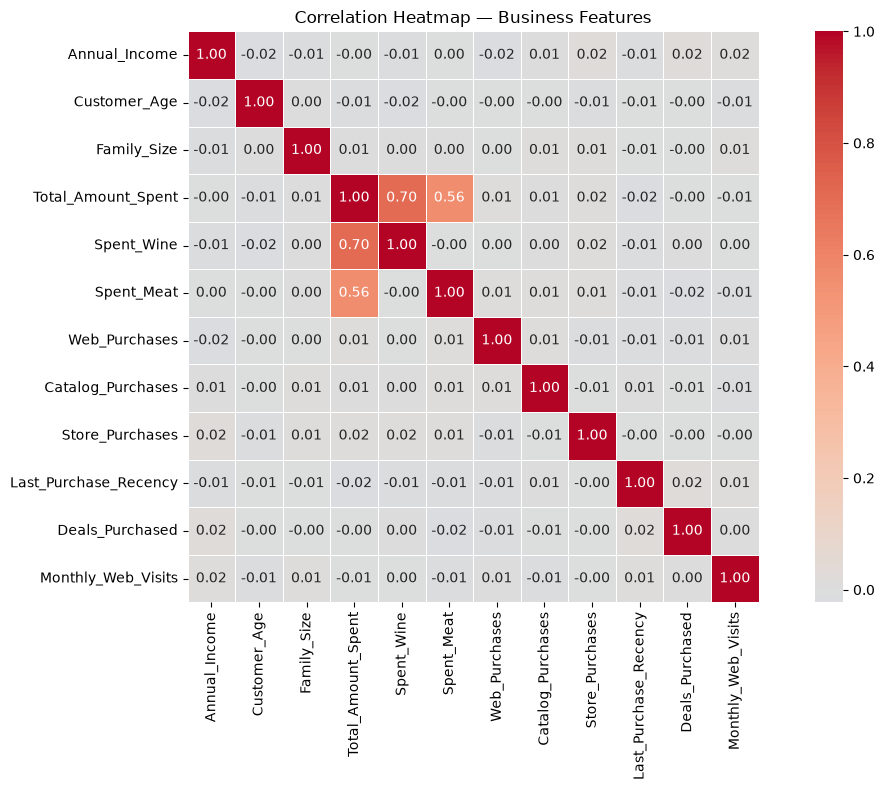

In [29]:
# Correlation heatmap for key business features only

business_features = [
    'Annual_Income',
    'Customer_Age',
    'Family_Size',
    'Total_Amount_Spent',
    'Spent_Wine',
    'Spent_Meat',
    'Web_Purchases',
    'Catalog_Purchases',
    'Store_Purchases',
    'Last_Purchase_Recency',
    'Deals_Purchased',
    'Monthly_Web_Visits'
]

business_corr = df[business_features].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    business_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)

plt.title('Correlation Heatmap — Business Features')
plt.tight_layout()
plt.show()

### Outlier Detection Using IQR

In [30]:
# Select numerical columns
numeric_data = df.select_dtypes(include=np.number)

Q1 = numeric_data.quantile(0.25)

Q3 = numeric_data.quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outlier_count = (
    (numeric_data < lower_limit) |
    (numeric_data > upper_limit)
).sum()

outlier_count[outlier_count > 0]

Annual_Income         52
Total_Amount_Spent     6
dtype: int64

### Cap Annual Income Outliers

In [31]:
# Cap Annual Income outliers using the IQR limits calculated above
income_lower = lower_limit['Annual_Income']
income_upper = upper_limit['Annual_Income']

print('Annual Income IQR lower limit:', round(income_lower, 2))
print('Annual Income IQR upper limit:', round(income_upper, 2))
print(
    'Outliers before capping:',
    ((df['Annual_Income'] < income_lower) | (df['Annual_Income'] > income_upper)).sum()
)

df['Annual_Income'] = df['Annual_Income'].clip(
    lower=income_lower,
    upper=income_upper
)

print(
    'Outliers after capping:',
    ((df['Annual_Income'] < income_lower) | (df['Annual_Income'] > income_upper)).sum()
)
print('Annual Income min after capping:', round(df['Annual_Income'].min(), 2))
print('Annual Income max after capping:', round(df['Annual_Income'].max(), 2))

Annual Income IQR lower limit: 9019.78
Annual Income IQR upper limit: 90682.45
Outliers before capping: 52
Outliers after capping: 0
Annual Income min after capping: 9019.78
Annual Income max after capping: 90682.45


### Boxplot for Outliers

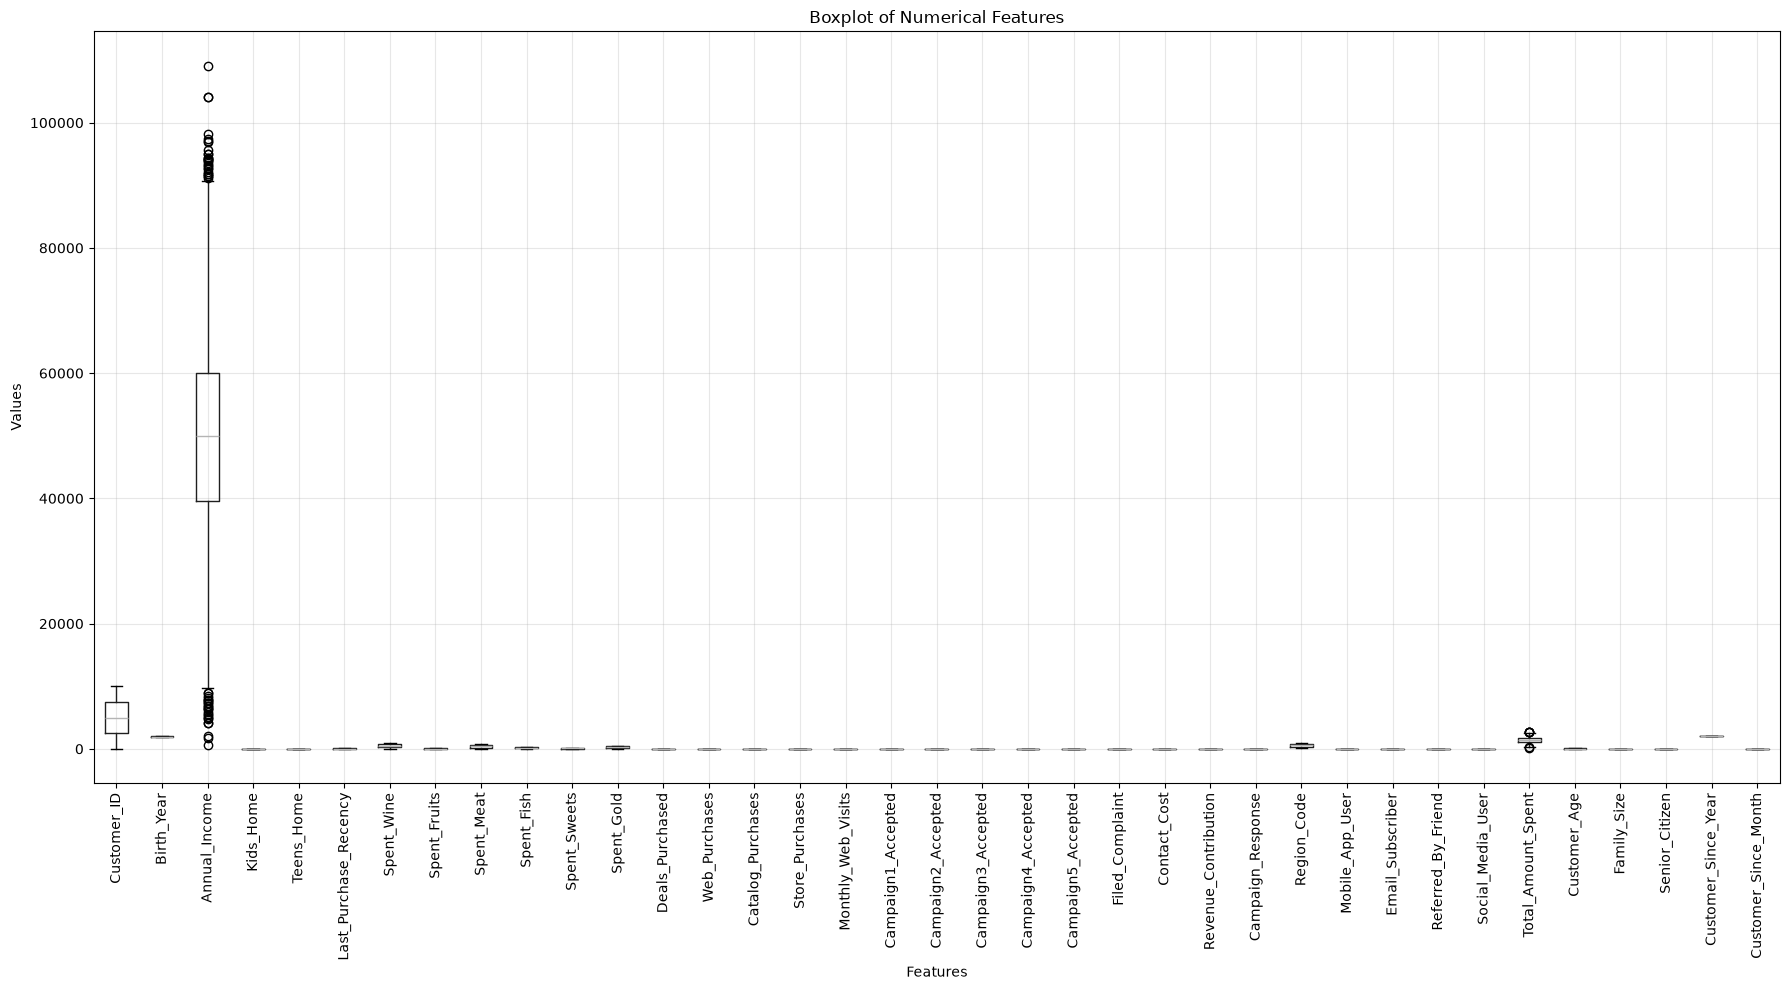

In [32]:
# Create boxplots for numerical features

plt.figure(figsize=(18, 10))

numeric_data.boxplot()

plt.title('Boxplot of Numerical Features')
plt.xlabel('Features')
plt.ylabel('Values')

plt.xticks(rotation=90)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Annual Income Distribution

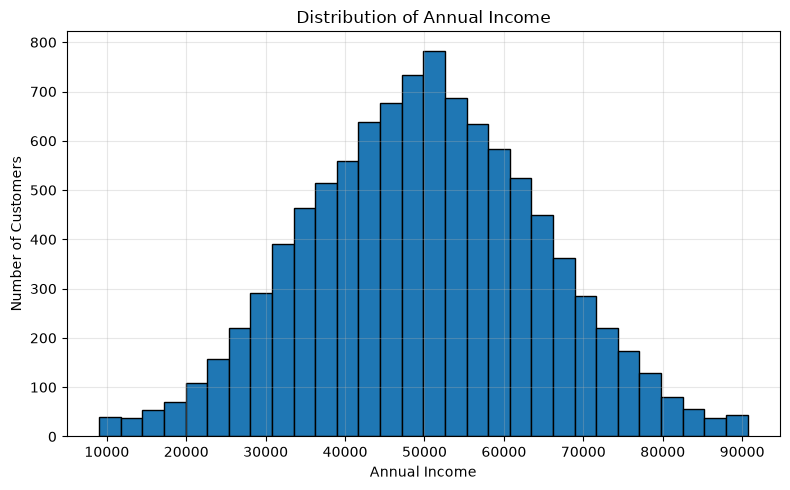

In [33]:
# Plot the distribution of Annual Income

plt.figure(figsize=(8, 5))

plt.hist(
    df['Annual_Income'],
    bins=30,
    edgecolor='black'
)

plt.xlabel('Annual Income')
plt.ylabel('Number of Customers')
plt.title('Distribution of Annual Income')

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Customer Age Distribution

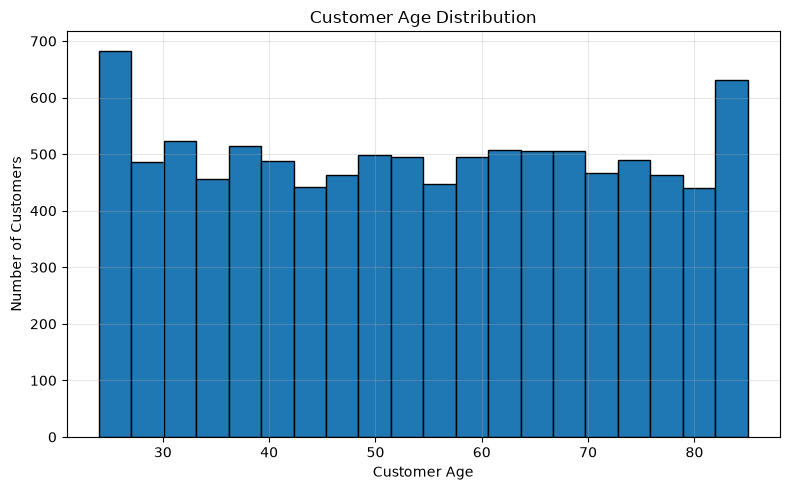

In [34]:
# Plot customer age distribution

plt.figure(figsize=(8, 5))

plt.hist(
    df['Customer_Age'],
    bins=20,
    edgecolor='black'
)

plt.xlabel('Customer Age')
plt.ylabel('Number of Customers')
plt.title('Customer Age Distribution')

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Membership Tier

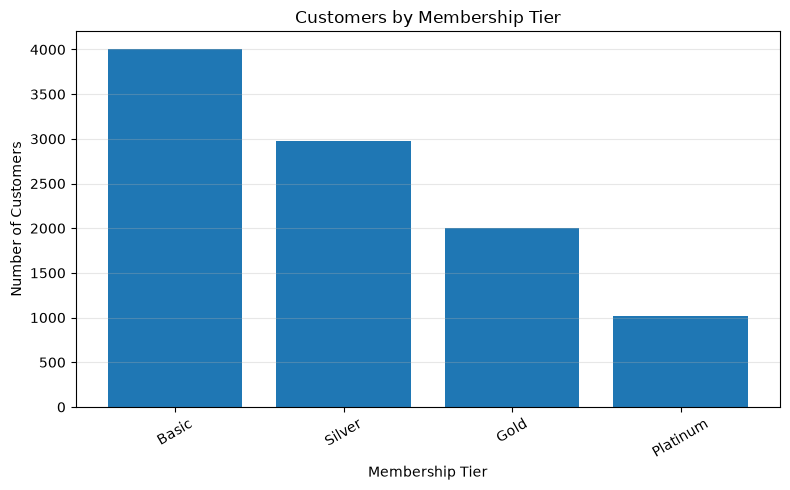

In [35]:
# Count customers in each membership tier

membership_counts = df['Membership_Tier'].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(
    membership_counts.index,
    membership_counts.values
)

plt.xlabel('Membership Tier')
plt.ylabel('Number of Customers')
plt.title('Customers by Membership Tier')

plt.xticks(rotation=30)

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Education Level

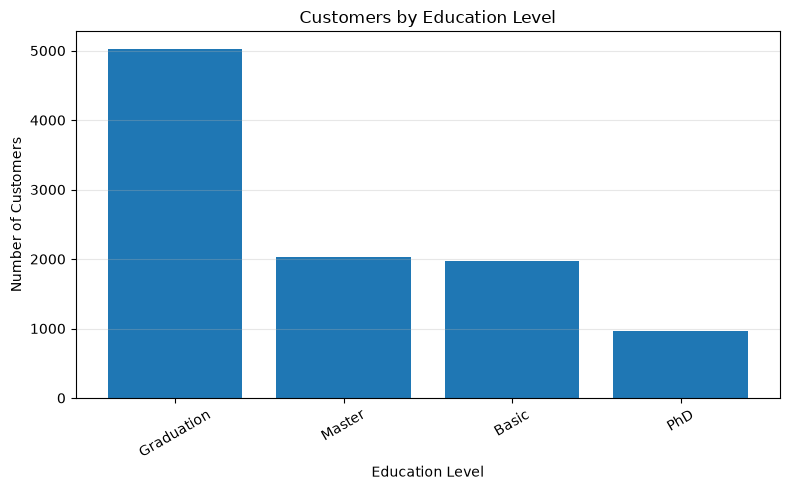

In [36]:
# Count customers by education level

education_counts = df['Education_Level'].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(
    education_counts.index,
    education_counts.values
)

plt.xlabel('Education Level')
plt.ylabel('Number of Customers')
plt.title('Customers by Education Level')

plt.xticks(rotation=30)

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Spending Categories

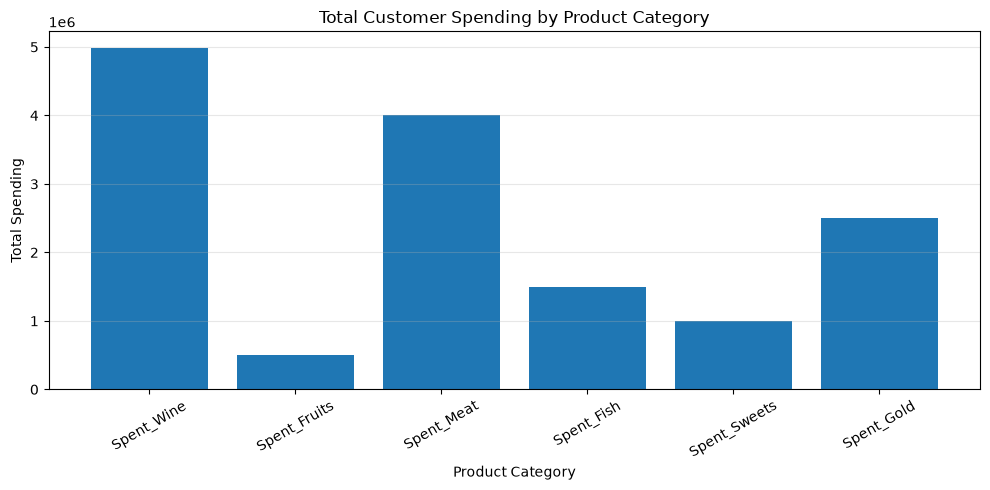

In [37]:
# Compare total spending across product categories

spending_columns = [
    'Spent_Wine',
    'Spent_Fruits',
    'Spent_Meat',
    'Spent_Fish',
    'Spent_Sweets',
    'Spent_Gold'
]

spending_totals = df[spending_columns].sum()

plt.figure(figsize=(10, 5))

plt.bar(
    spending_totals.index,
    spending_totals.values
)

plt.xlabel('Product Category')
plt.ylabel('Total Spending')
plt.title('Total Customer Spending by Product Category')

plt.xticks(rotation=30)

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Purchase Channels

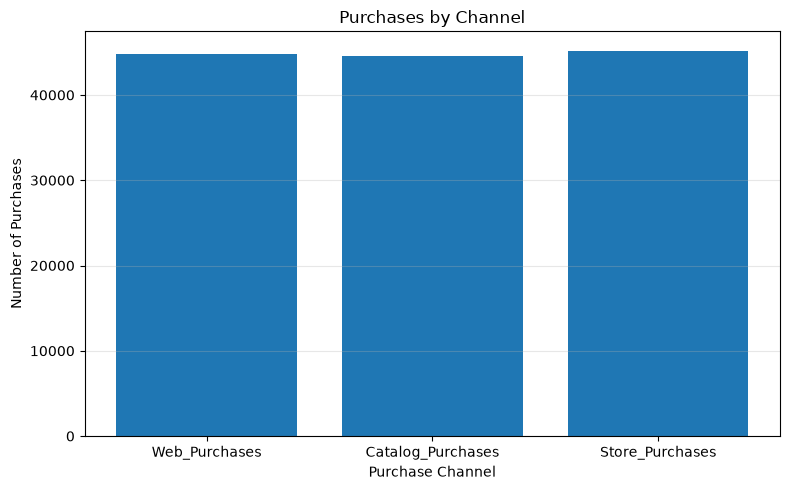

In [38]:
# Compare purchases through different channels

purchase_columns = [
    'Web_Purchases',
    'Catalog_Purchases',
    'Store_Purchases'
]

purchase_totals = df[purchase_columns].sum()

plt.figure(figsize=(8, 5))

plt.bar(
    purchase_totals.index,
    purchase_totals.values
)

plt.xlabel('Purchase Channel')
plt.ylabel('Number of Purchases')
plt.title('Purchases by Channel')

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Annual Income vs Total Amount Spent

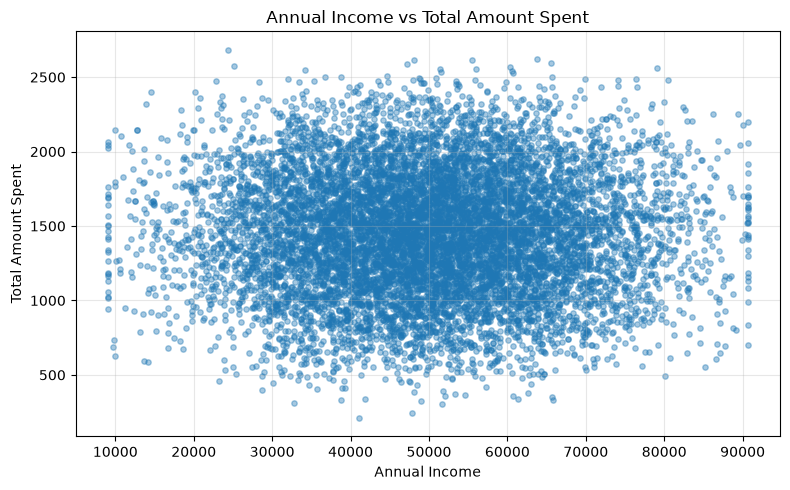

In [39]:
# Scatter plot of Annual Income vs Total Amount Spent

plt.figure(figsize=(8, 5))

plt.scatter(
    df['Annual_Income'],
    df['Total_Amount_Spent'],
    alpha=0.4,
    s=15
)

plt.xlabel('Annual Income')
plt.ylabel('Total Amount Spent')
plt.title('Annual Income vs Total Amount Spent')

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Business Features Correlation Heatmap

### Handle Numerical and Categorical Features

In [40]:
# Create a copy of the cleaned dataset
data = df.copy()

# Remove Customer_ID because it is only an identifier
# Remove Customer_Since because we already extracted useful date features
# Remove constant columns because they do not provide information for clustering
# Remove Birth_Year because it is fully redundant with Customer_Age
data = data.drop(
    columns=[
        'Customer_ID',
        'Customer_Since',
        'Contact_Cost',
        'Revenue_Contribution',
        'Birth_Year'
    ]
)

# Display the remaining columns
data.columns

Index(['Education_Level', 'Marital_Status', 'Annual_Income', 'Kids_Home',
       'Teens_Home', 'Last_Purchase_Recency', 'Spent_Wine', 'Spent_Fruits',
       'Spent_Meat', 'Spent_Fish', 'Spent_Sweets', 'Spent_Gold',
       'Deals_Purchased', 'Web_Purchases', 'Catalog_Purchases',
       'Store_Purchases', 'Monthly_Web_Visits', 'Campaign1_Accepted',
       'Campaign2_Accepted', 'Campaign3_Accepted', 'Campaign4_Accepted',
       'Campaign5_Accepted', 'Filed_Complaint', 'Campaign_Response', 'Country',
       'City', 'Region_Code', 'Mobile_App_User', 'Email_Subscriber',
       'Device_Type', 'Referred_By_Friend', 'Social_Media_User',
       'Membership_Tier', 'Total_Amount_Spent', 'Customer_Age', 'Family_Size',
       'Senior_Citizen', 'Customer_Since_Year', 'Customer_Since_Month'],
      dtype='str')

### Separate Numerical and Categorical Features

In [41]:
numerical_features = data.select_dtypes(
    include=np.number
).columns

categorical_features = data.select_dtypes(
    exclude=np.number
).columns

numerical_features

Index(['Annual_Income', 'Kids_Home', 'Teens_Home', 'Last_Purchase_Recency',
       'Spent_Wine', 'Spent_Fruits', 'Spent_Meat', 'Spent_Fish',
       'Spent_Sweets', 'Spent_Gold', 'Deals_Purchased', 'Web_Purchases',
       'Catalog_Purchases', 'Store_Purchases', 'Monthly_Web_Visits',
       'Campaign1_Accepted', 'Campaign2_Accepted', 'Campaign3_Accepted',
       'Campaign4_Accepted', 'Campaign5_Accepted', 'Filed_Complaint',
       'Campaign_Response', 'Region_Code', 'Mobile_App_User',
       'Email_Subscriber', 'Referred_By_Friend', 'Social_Media_User',
       'Total_Amount_Spent', 'Customer_Age', 'Family_Size', 'Senior_Citizen',
       'Customer_Since_Year', 'Customer_Since_Month'],
      dtype='str')

In [42]:
categorical_features

Index(['Education_Level', 'Marital_Status', 'Country', 'City', 'Device_Type',
       'Membership_Tier'],
      dtype='str')

### Convert Categorical Features

In [43]:
data_encoded = pd.get_dummies(
    data,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

# Display the encoded dataset
data_encoded.head()

,Annual_Income,Kids_Home,Teens_Home,Last_Purchase_Recency,Spent_Wine,Spent_Fruits,Spent_Meat,Spent_Fish,Spent_Sweets,Spent_Gold,...,Country_USA,City_London,City_Mumbai,City_New York,City_São Paulo,Device_Type_Mobile,Device_Type_Tablet,Membership_Tier_Gold,Membership_Tier_Platinum,Membership_Tier_Silver
0,40175.23,1,1,68,440,34,473,215,58,45,...,0,0,1,0,0,0,0,0,0,1
1,27979.68,0,1,99,826,24,183,89,168,357,...,0,0,1,0,0,0,0,0,0,0
2,64747.68,0,0,63,895,2,315,104,195,295,...,0,0,1,0,0,0,0,0,0,1
3,50185.85,2,2,65,127,50,594,104,97,235,...,0,1,0,0,0,1,0,0,0,0
4,53163.09,1,2,49,140,49,74,213,173,285,...,0,0,1,0,0,1,0,0,0,0


### Standard Scaling

In [44]:
# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Create the StandardScaler object
scaler = StandardScaler()

# Scale all numerical features
X_scaled = scaler.fit_transform(data_encoded)

# Convert the scaled array back into a DataFrame
X_scaled = pd.DataFrame(
    X_scaled,
    columns=data_encoded.columns,
    index=data_encoded.index
)

# Display the scaled features
X_scaled.head()

,Annual_Income,Kids_Home,Teens_Home,Last_Purchase_Recency,Spent_Wine,Spent_Fruits,Spent_Meat,Spent_Fish,Spent_Sweets,Spent_Gold,...,Country_USA,City_London,City_Mumbai,City_New York,City_São Paulo,Device_Type_Mobile,Device_Type_Tablet,Membership_Tier_Gold,Membership_Tier_Platinum,Membership_Tier_Silver
0,-0.662536,0.003299,0.013131,0.632555,-0.201197,-0.544477,0.310679,0.763402,-0.720256,-1.430966,...,-0.489822,-0.499687,2.042212,-0.515114,-0.497812,-0.985308,-0.330176,-0.500937,-0.335736,1.535565
1,-1.488664,-1.218675,0.013131,1.697839,1.139460,-0.891080,-0.945763,-0.689695,1.197075,0.739250,...,-0.489822,-0.499687,2.042212,-0.515114,-0.497812,-0.985308,-0.330176,-0.500937,-0.335736,-0.651226
2,1.002005,-1.218675,-1.214084,0.460735,1.379111,-1.653604,-0.373865,-0.516708,1.667692,0.307989,...,-0.489822,-0.499687,2.042212,-0.515114,-0.497812,-0.985308,-0.330176,-0.500937,-0.335736,1.535565
3,0.015585,1.225274,1.240346,0.529463,-1.288310,0.010086,0.834918,-0.516708,-0.040475,-0.109360,...,-0.489822,2.001251,-0.489665,-0.515114,-0.497812,1.014911,-0.330176,-0.500937,-0.335736,-0.651226
4,0.217264,0.003299,1.240346,-0.020361,-1.243159,-0.024574,-1.418012,0.740337,1.284226,0.238431,...,-0.489822,-0.499687,2.042212,-0.515114,-0.497812,1.014911,-0.330176,-0.500937,-0.335736,-0.651226


## KMeans Clustering

In [45]:
# Import KMeans
from sklearn.cluster import KMeans

# Use the Elbow Method to find the optimal number of clusters
# Test K values from 2 to 10
k_range = range(2, 11)
inertias = []

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10,
        max_iter=300
    )
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

print('Inertia values for each K:')
for k, inertia in zip(k_range, inertias):
    print(f'  K={k}: {inertia:,.2f}')

Inertia values for each K:
  K=2: 515,914.20
  K=3: 503,363.53
  K=4: 495,998.01
  K=5: 488,073.84
  K=6: 479,523.87
  K=7: 474,641.00
  K=8: 471,665.92
  K=9: 468,257.50
  K=10: 466,847.71


### Elbow Method Plot

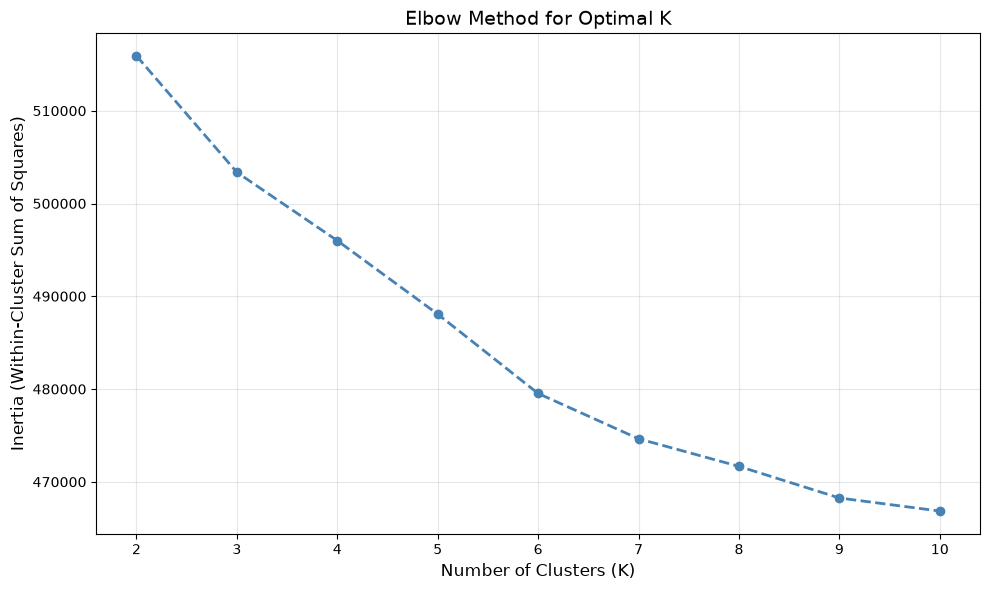

In [46]:
# Plot the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(list(k_range), inertias, marker='o', linestyle='--', color='steelblue', linewidth=2)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
plt.title('Elbow Method for Optimal K', fontsize=14)
plt.xticks(list(k_range))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Silhouette Score Analysis

In [47]:
# Import silhouette_score
from sklearn.metrics import silhouette_score

# Calculate Silhouette Score for each K
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10,
        max_iter=300
    )
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

print('Silhouette Scores for each K:')
for k, score in zip(k_range, silhouette_scores):
    print(f'  K={k}: {score:.4f}')

# Identify the best K based on the highest Silhouette Score
best_k = list(k_range)[silhouette_scores.index(max(silhouette_scores))]
print(f'\nBest K based on Silhouette Score: {best_k}')

Silhouette Scores for each K:
  K=2: 0.0264
  K=3: 0.0352
  K=4: 0.0267
  K=5: 0.0340
  K=6: 0.0352
  K=7: 0.0274
  K=8: 0.0279
  K=9: 0.0251
  K=10: 0.0235

Best K based on Silhouette Score: 3


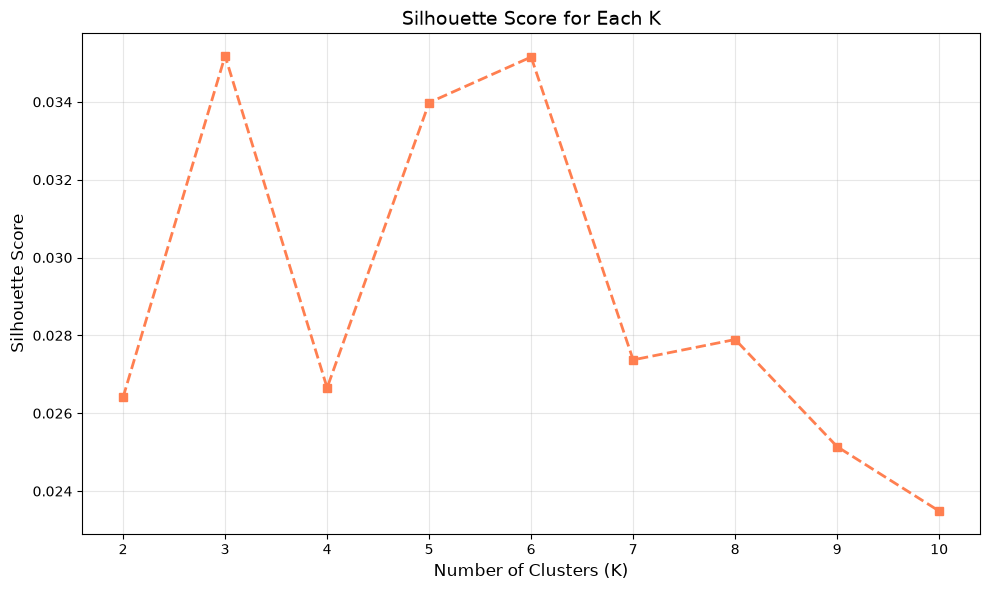

In [48]:
# Plot the Silhouette Scores
plt.figure(figsize=(10, 6))
plt.plot(list(k_range), silhouette_scores, marker='s', linestyle='--', color='coral', linewidth=2)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Score for Each K', fontsize=14)
plt.xticks(list(k_range))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Fit KMeans with Optimal K

In [49]:
# Fit KMeans with the optimal number of clusters
optimal_k = best_k

kmeans_final = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10,
    max_iter=300
)

# Predict cluster labels
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Add the cluster labels to the original dataframe
df['Cluster'] = cluster_labels

# Also add to the working copy
data['Cluster'] = cluster_labels

print(f'KMeans fitted with K={optimal_k}')
print(f'\nCluster distribution:')
print(df['Cluster'].value_counts().sort_index())

KMeans fitted with K=3

Cluster distribution:
Cluster
0     983
1    3594
2    5423
Name: count, dtype: int64


### Cluster Profiling

In [50]:
# Profile each cluster using the key numerical features
profile_columns = [
    'Annual_Income', 'Total_Amount_Spent', 'Customer_Age',
    'Spent_Wine', 'Spent_Meat', 'Spent_Fish', 'Spent_Fruits',
    'Spent_Sweets', 'Spent_Gold',
    'Web_Purchases', 'Store_Purchases', 'Catalog_Purchases',
    'Deals_Purchased', 'Monthly_Web_Visits',
    'Last_Purchase_Recency', 'Family_Size',
    'Kids_Home', 'Teens_Home'
]

cluster_profile = df.groupby('Cluster')[profile_columns].mean().round(2)
cluster_profile

,Annual_Income,Total_Amount_Spent,Customer_Age,Spent_Wine,Spent_Meat,Spent_Fish,Spent_Fruits,Spent_Sweets,Spent_Gold,Web_Purchases,Store_Purchases,Catalog_Purchases,Deals_Purchased,Monthly_Web_Visits,Last_Purchase_Recency,Family_Size,Kids_Home,Teens_Home
Cluster,,,,,,,,,,,,,,,,,,
0,49015.40,1435.61,54.96,481.58,399.13,154.66,49.32,99.74,251.19,4.49,4.51,4.47,4.42,9.51,50.34,2.40,1.05,0.97
1,49582.01,1436.53,72.74,489.94,399.95,149.08,49.78,99.36,248.42,4.48,4.48,4.46,4.53,9.46,48.93,2.38,0.99,1.00
2,50373.94,1457.44,41.78,506.19,402.58,147.56,49.73,99.22,252.16,4.49,4.55,4.45,4.52,9.47,49.89,2.37,0.99,0.98


### Cluster Visualizations

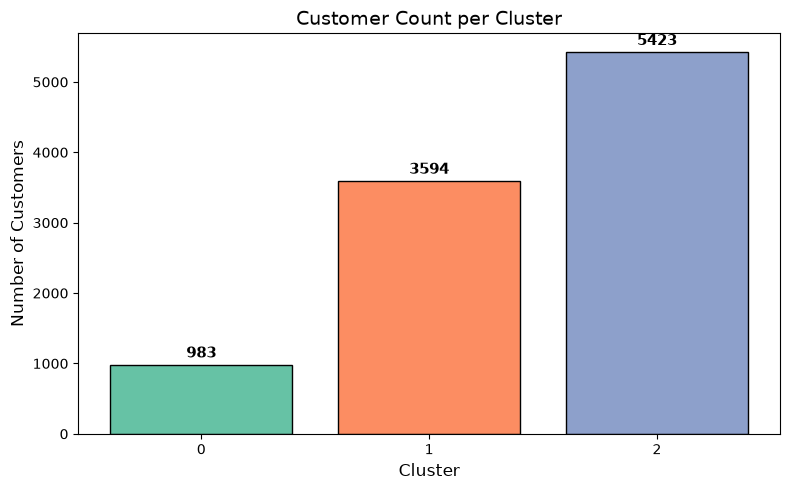

In [51]:
# Cluster size distribution
cluster_counts = df['Cluster'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
colors = sns.color_palette('Set2', n_colors=optimal_k)
bars = plt.bar(cluster_counts.index, cluster_counts.values, color=colors, edgecolor='black')

# Add count labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2., height + 50,
        f'{int(height)}',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.title('Customer Count per Cluster', fontsize=14)
plt.xticks(cluster_counts.index)
plt.tight_layout()
plt.show()

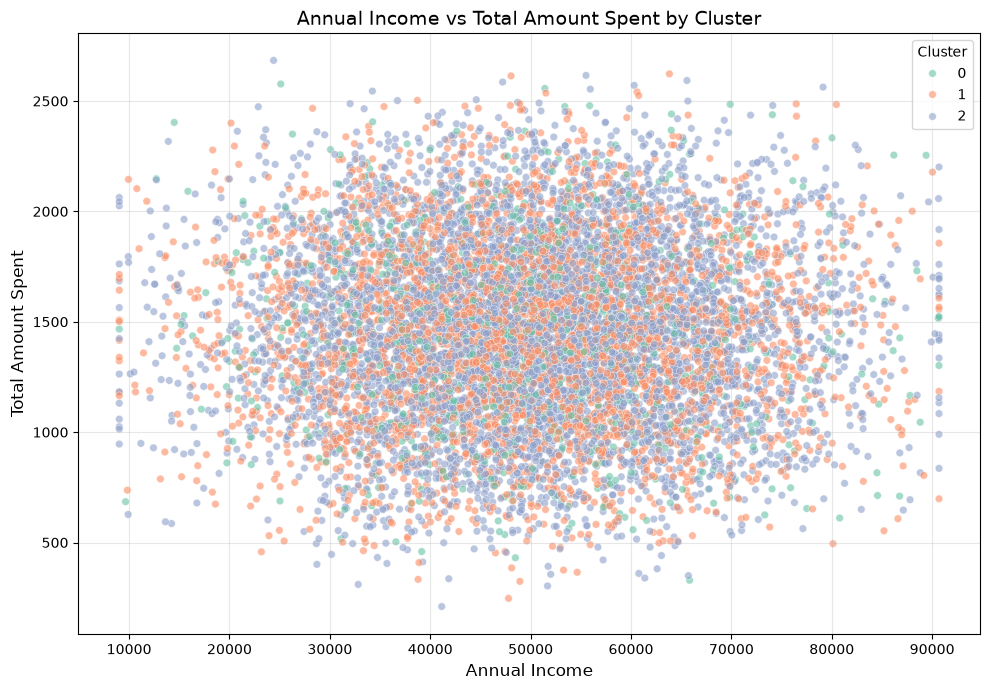

In [52]:
# Scatter plot: Annual Income vs Total Amount Spent by Cluster
plt.figure(figsize=(10, 7))
scatter = sns.scatterplot(
    data=df, x='Annual_Income', y='Total_Amount_Spent',
    hue='Cluster', palette='Set2', alpha=0.6, s=30
)
plt.xlabel('Annual Income', fontsize=12)
plt.ylabel('Total Amount Spent', fontsize=12)
plt.title('Annual Income vs Total Amount Spent by Cluster', fontsize=14)
plt.legend(title='Cluster', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\maram\AppData\Local\Temp\ipykernel_22016\737231616.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\maram\AppData\Local\Temp\ipykernel_22016\737231616.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\maram\AppData\Local\Temp\ipykernel_22016\737231616.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\maram\AppData\Local\Temp\ipykernel_22016\737231616.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and 

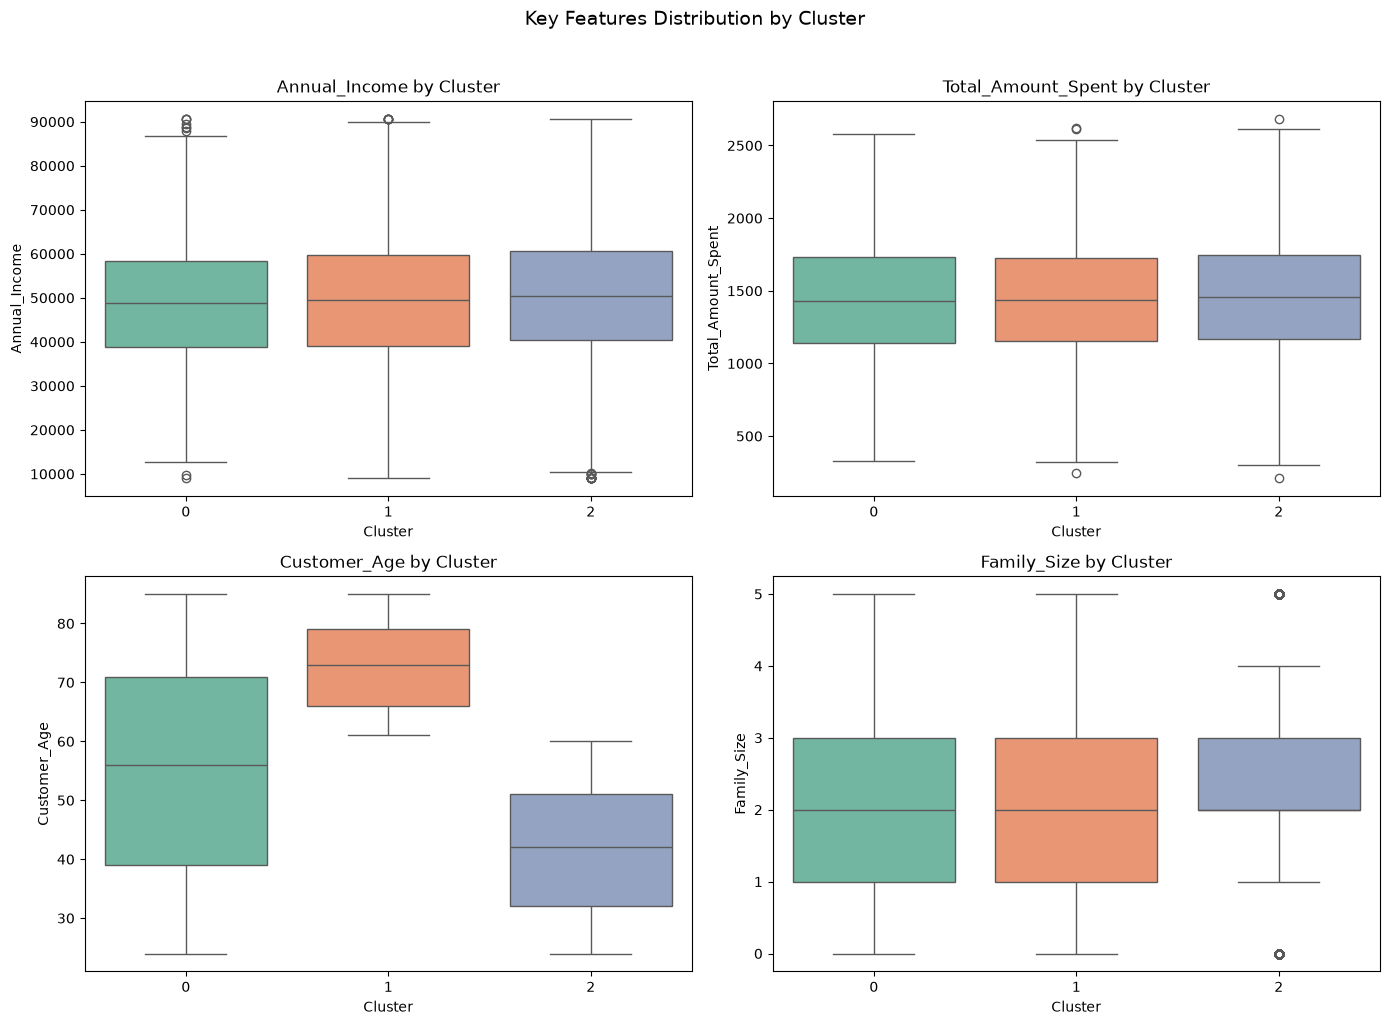

In [53]:
# Boxplots for key features by cluster
key_features = ['Annual_Income', 'Total_Amount_Spent', 'Customer_Age', 'Family_Size']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, feature in enumerate(key_features):
    ax = axes[i // 2][i % 2]
    sns.boxplot(
        data=df, x='Cluster', y=feature,
        palette='Set2', ax=ax
    )
    ax.set_title(f'{feature} by Cluster', fontsize=12)
    ax.set_xlabel('Cluster', fontsize=10)
    ax.set_ylabel(feature, fontsize=10)

plt.suptitle('Key Features Distribution by Cluster', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

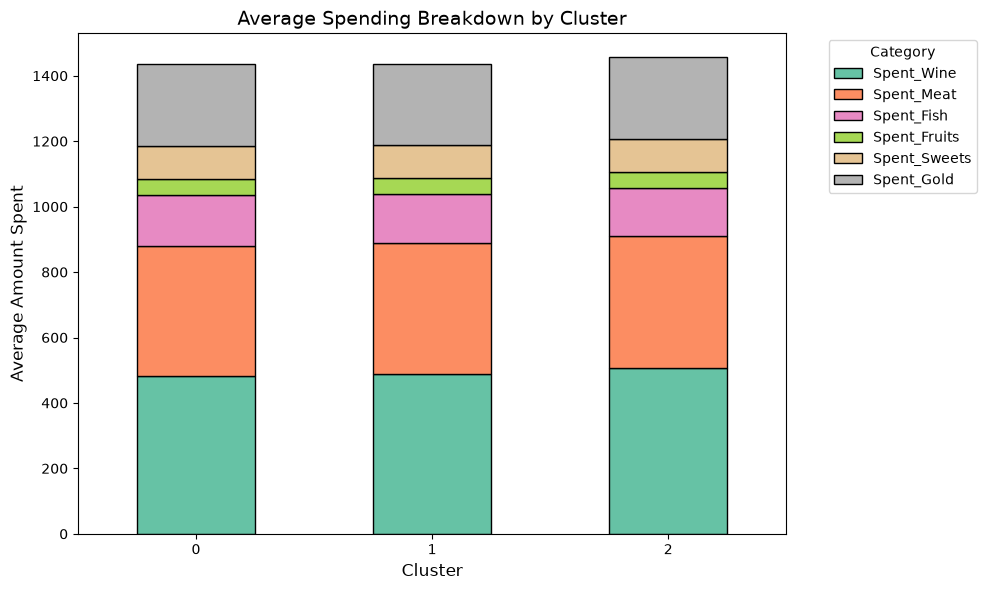

In [54]:
# Average spending breakdown by cluster
spending_cols = ['Spent_Wine', 'Spent_Meat', 'Spent_Fish', 'Spent_Fruits', 'Spent_Sweets', 'Spent_Gold']
spending_by_cluster = df.groupby('Cluster')[spending_cols].mean()

spending_by_cluster.plot(
    kind='bar', stacked=True, figsize=(10, 6),
    colormap='Set2', edgecolor='black'
)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Average Amount Spent', fontsize=12)
plt.title('Average Spending Breakdown by Cluster', fontsize=14)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

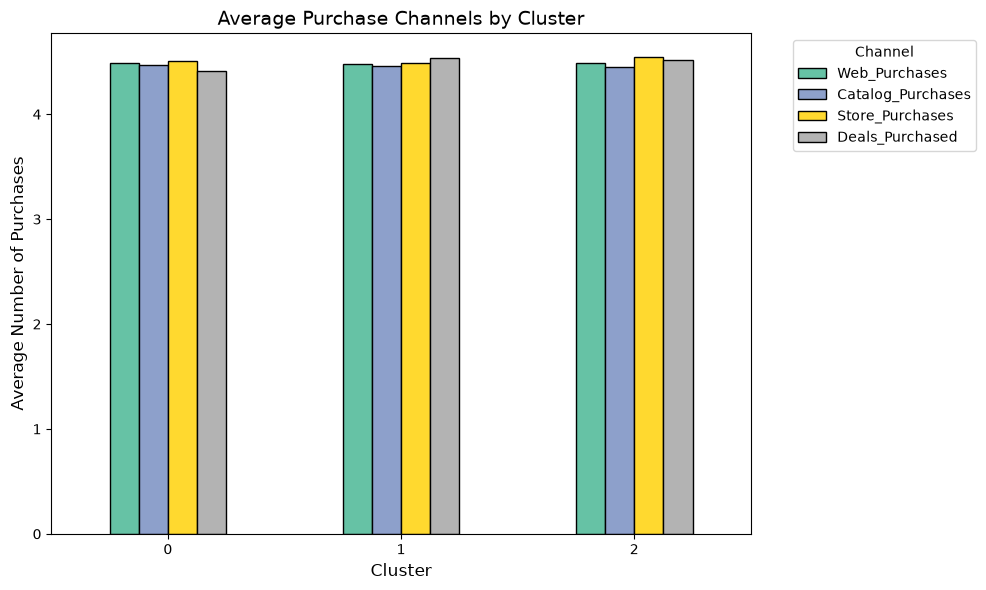

In [55]:
# Average purchase channels by cluster
channel_cols = ['Web_Purchases', 'Catalog_Purchases', 'Store_Purchases', 'Deals_Purchased']
channels_by_cluster = df.groupby('Cluster')[channel_cols].mean()

channels_by_cluster.plot(
    kind='bar', figsize=(10, 6),
    colormap='Set2', edgecolor='black'
)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Average Number of Purchases', fontsize=12)
plt.title('Average Purchase Channels by Cluster', fontsize=14)
plt.legend(title='Channel', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

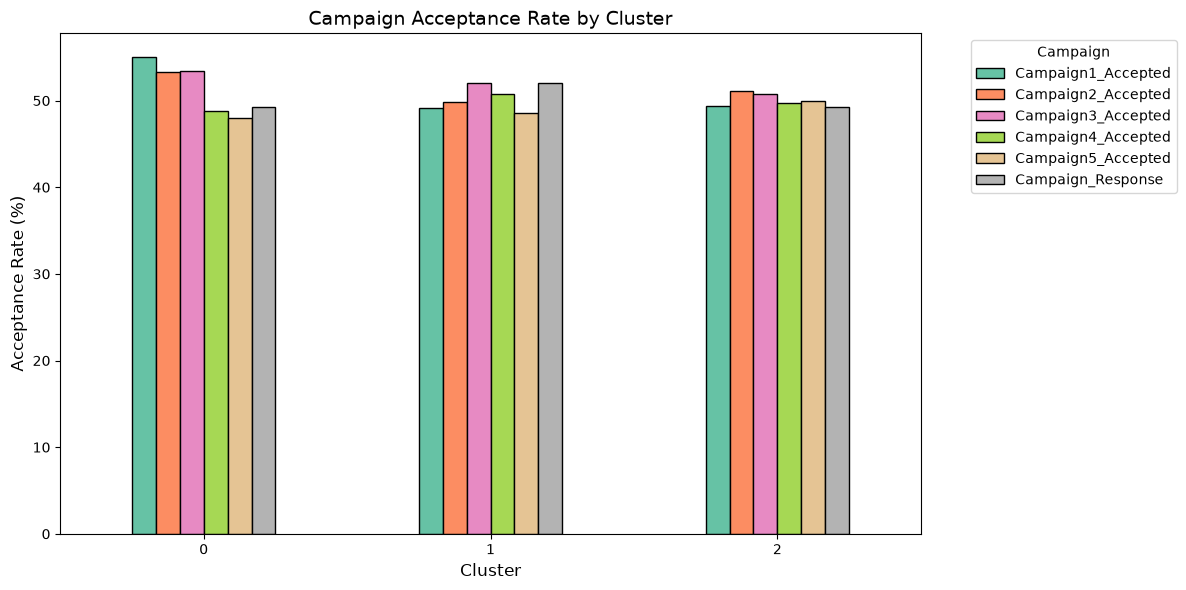

In [56]:
# Campaign acceptance rate by cluster
campaign_cols = [
    'Campaign1_Accepted', 'Campaign2_Accepted', 'Campaign3_Accepted',
    'Campaign4_Accepted', 'Campaign5_Accepted', 'Campaign_Response'
]

campaign_by_cluster = df.groupby('Cluster')[campaign_cols].mean().round(4) * 100

campaign_by_cluster.plot(
    kind='bar', figsize=(12, 6),
    colormap='Set2', edgecolor='black'
)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Acceptance Rate (%)', fontsize=12)
plt.title('Campaign Acceptance Rate by Cluster', fontsize=14)
plt.legend(title='Campaign', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### PCA Visualization of Clusters

Explained variance ratio: [0.03832857 0.03765934]
Total explained variance: 0.0760


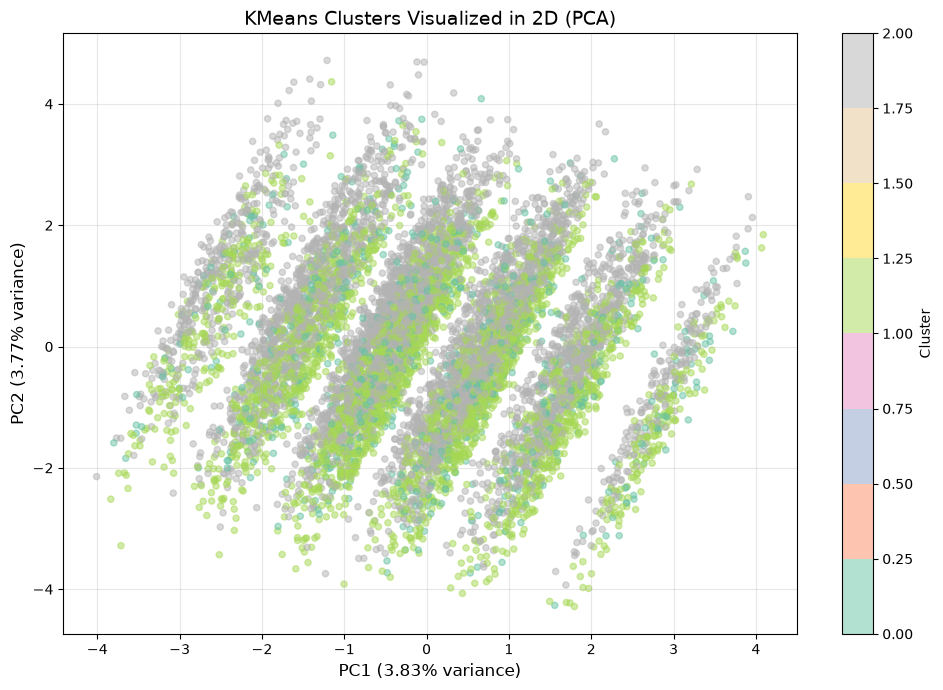

In [57]:
# Reduce dimensions using PCA for 2D visualization
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f'Explained variance ratio: {pca.explained_variance_ratio_}')
print(f'Total explained variance: {sum(pca.explained_variance_ratio_):.4f}')

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=cluster_labels, cmap='Set2', alpha=0.5, s=20
)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
plt.title('KMeans Clusters Visualized in 2D (PCA)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Cluster Summary with Categorical Features

In [58]:
# Categorical feature breakdown by cluster
cat_features = ['Education_Level', 'Marital_Status', 'Membership_Tier', 'Device_Type']

for feature in cat_features:
    print(f'\n--- {feature} Distribution by Cluster ---')
    ct = pd.crosstab(df['Cluster'], df[feature], normalize='index').round(4) * 100
    print(ct)
    print()


--- Education_Level Distribution by Cluster ---
Education_Level  Basic  Graduation  Master   PhD
Cluster                                         
0                19.53       51.37   20.04  9.05
1                20.34       50.00   20.01  9.65
2                19.42       50.25   20.47  9.87


--- Marital_Status Distribution by Cluster ---
Marital_Status  Divorced  Married  Single  Together  Widow
Cluster                                                   
0                  22.28    18.51   20.55     19.84  18.82
1                  21.37    19.34   19.25     18.75  21.29
2                  19.80    19.73   19.95     19.69  20.82


--- Membership_Tier Distribution by Cluster ---
Membership_Tier  Basic   Gold  Platinum  Silver
Cluster                                        
0                37.84  19.33     11.19   31.64
1                40.26  20.26      9.65   29.83
2                40.27  20.06     10.25   29.41


--- Device_Type Distribution by Cluster ---
Device_Type  Desktop  Mobi

In [59]:
# Final cluster summary table
summary_cols = [
    'Annual_Income', 'Total_Amount_Spent', 'Customer_Age',
    'Family_Size', 'Last_Purchase_Recency',
    'Monthly_Web_Visits', 'Deals_Purchased'
]

cluster_summary = df.groupby('Cluster').agg(
    Count=('Cluster', 'size'),
    Avg_Income=('Annual_Income', 'mean'),
    Avg_Spending=('Total_Amount_Spent', 'mean'),
    Avg_Age=('Customer_Age', 'mean'),
    Avg_Family_Size=('Family_Size', 'mean'),
    Avg_Recency=('Last_Purchase_Recency', 'mean'),
    Avg_Web_Visits=('Monthly_Web_Visits', 'mean'),
    Avg_Deals=('Deals_Purchased', 'mean')
).round(2)

print('=== Final Cluster Summary ===')
cluster_summary

=== Final Cluster Summary ===


,Count,Avg_Income,Avg_Spending,Avg_Age,Avg_Family_Size,Avg_Recency,Avg_Web_Visits,Avg_Deals
Cluster,,,,,,,,
0,983,49015.40,1435.61,54.96,2.40,50.34,9.51,4.42
1,3594,49582.01,1436.53,72.74,2.38,48.93,9.46,4.53
2,5423,50373.94,1457.44,41.78,2.37,49.89,9.47,4.52


## Hierarchical (Agglomerative) Clustering

In [60]:
# 1. Imports and setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram

# Preserve the K selected in the preceding K-Means analysis.
if 'optimal_k' not in globals():
    optimal_k = 3

X_hier = X_scaled.to_numpy() if isinstance(X_scaled, pd.DataFrame) else np.asarray(X_scaled)

print("Data shape:", X_hier.shape)
print("Number of clusters:", optimal_k)

Data shape: (10000, 53)
Number of clusters: 3


In [61]:
# 2. Fit Ward-linkage agglomerative clustering
hierarchical_model = AgglomerativeClustering(
    n_clusters=optimal_k,
    linkage='ward'
 )

hierarchical_labels = hierarchical_model.fit_predict(X_hier)

# Keep hierarchical labels separate from the K-Means labels.
df['Hierarchical_Cluster'] = hierarchical_labels

print("Hierarchical clustering completed.")
print("\nCluster counts:")
print(df['Hierarchical_Cluster'].value_counts().sort_index())

Hierarchical clustering completed.

Cluster counts:
Hierarchical_Cluster
0    8315
1     873
2     812
Name: count, dtype: int64


Dendrogram based on a sample of 1000 rows.


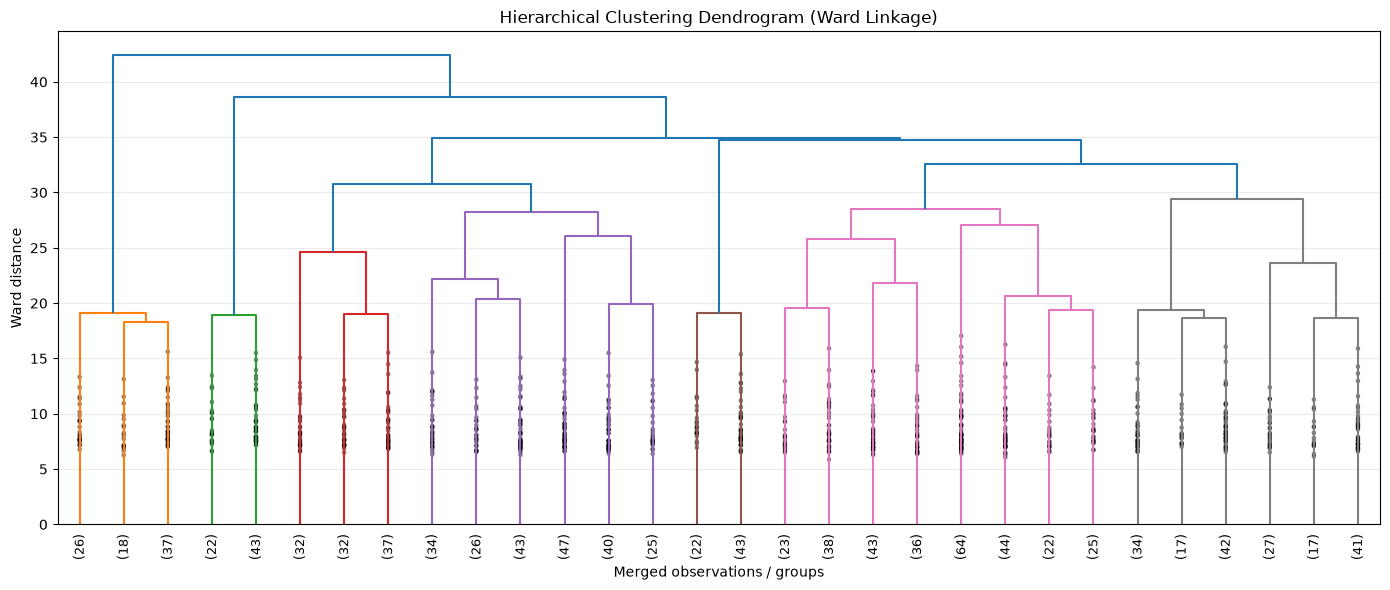

In [62]:
# 3. Dendrogram
# For large datasets, use a reproducible sample for display only.
max_dendrogram_rows = 1000

if len(X_hier) > max_dendrogram_rows:
    rng = np.random.default_rng(42)
    sample_idx = rng.choice(len(X_hier), size=max_dendrogram_rows, replace=False)
    X_dendrogram = X_hier[sample_idx]
    print(f"Dendrogram based on a sample of {max_dendrogram_rows} rows.")
else:
    X_dendrogram = X_hier
    print("Dendrogram based on all rows.")

linkage_matrix = linkage(X_dendrogram, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(
    linkage_matrix,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=9,
    show_contracted=True
)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Merged observations / groups')
plt.ylabel('Ward distance')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

In [63]:
# 4. Silhouette score and cluster-size percentages
n_found = len(np.unique(hierarchical_labels))

if 2 <= n_found < len(X_hier):
    hierarchical_silhouette = silhouette_score(X_hier, hierarchical_labels)
    print(f"Hierarchical Silhouette Score: {hierarchical_silhouette:.4f}")
else:
    hierarchical_silhouette = np.nan
    print("Silhouette score is undefined for this number of clusters.")

cluster_counts = pd.Series(hierarchical_labels).value_counts().sort_index()
cluster_percentages = (cluster_counts / len(hierarchical_labels) * 100).round(2)

hierarchical_distribution = pd.DataFrame({
    'Customer_Count': cluster_counts,
    'Percentage': cluster_percentages
})
display(hierarchical_distribution)

Hierarchical Silhouette Score: 0.0436


,Customer_Count,Percentage
0,8315,83.15
1,873,8.73
2,812,8.12


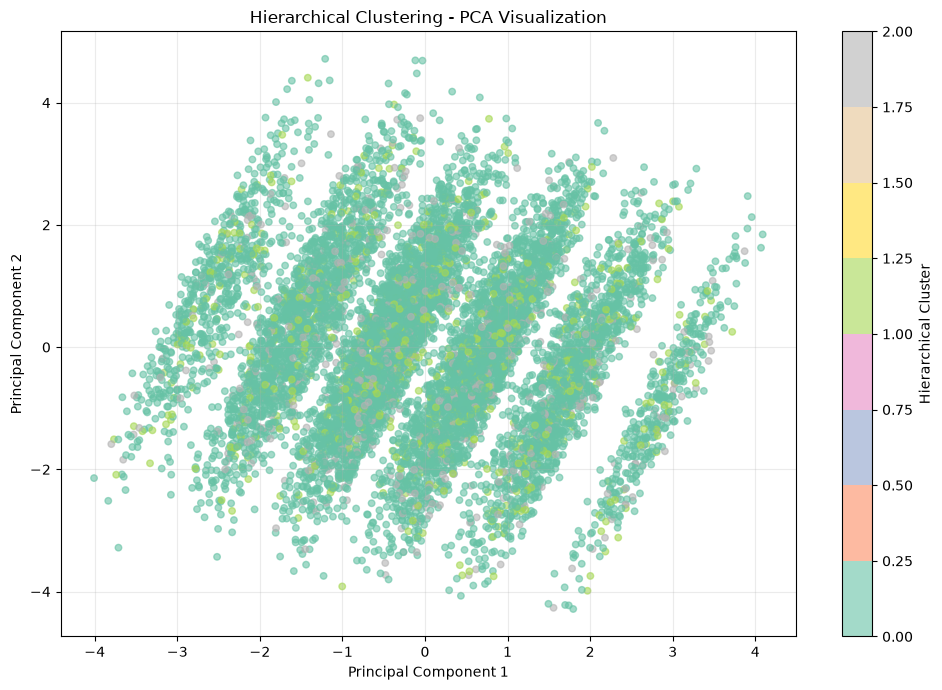

In [64]:
# 5. PCA visualization
# Reuse the K-Means projection when it is available.
if 'X_pca' not in globals():
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_hier)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=hierarchical_labels,
    cmap='Set2',
    alpha=0.6,
    s=22
)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Hierarchical Clustering - PCA Visualization')
plt.colorbar(scatter, label='Hierarchical Cluster')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [65]:
# 6. Cluster profiling with original, unscaled customer features
profile_columns = [
    'Annual_Income', 'Total_Amount_Spent', 'Customer_Age',
    'Spent_Wine', 'Spent_Meat', 'Spent_Fish', 'Spent_Fruits',
    'Spent_Sweets', 'Spent_Gold',
    'Web_Purchases', 'Store_Purchases', 'Catalog_Purchases',
    'Deals_Purchased', 'Monthly_Web_Visits', 'Last_Purchase_Recency',
    'Family_Size', 'Kids_Home', 'Teens_Home'
 ]

available_profile_columns = [col for col in profile_columns if col in df.columns]

hierarchical_profile = (
    df.groupby('Hierarchical_Cluster')[available_profile_columns]
      .mean()
      .round(2)
 )

display(hierarchical_profile)

,Annual_Income,Total_Amount_Spent,Customer_Age,Spent_Wine,Spent_Meat,Spent_Fish,Spent_Fruits,Spent_Sweets,Spent_Gold,Web_Purchases,Store_Purchases,Catalog_Purchases,Deals_Purchased,Monthly_Web_Visits,Last_Purchase_Recency,Family_Size,Kids_Home,Teens_Home
Hierarchical_Cluster,,,,,,,,,,,,,,,,,,
0,50099.33,1450.61,54.10,499.83,401.18,148.54,49.79,99.39,251.88,4.47,4.53,4.48,4.52,9.48,49.69,2.37,0.99,0.99
1,49625.61,1446.70,54.45,492.08,410.75,145.83,49.07,99.25,249.73,4.59,4.41,4.32,4.56,9.35,47.64,2.42,1.03,1.01
2,48840.71,1419.92,54.96,484.73,392.33,154.73,49.57,98.66,239.92,4.46,4.55,4.38,4.39,9.55,50.72,2.41,1.05,0.97


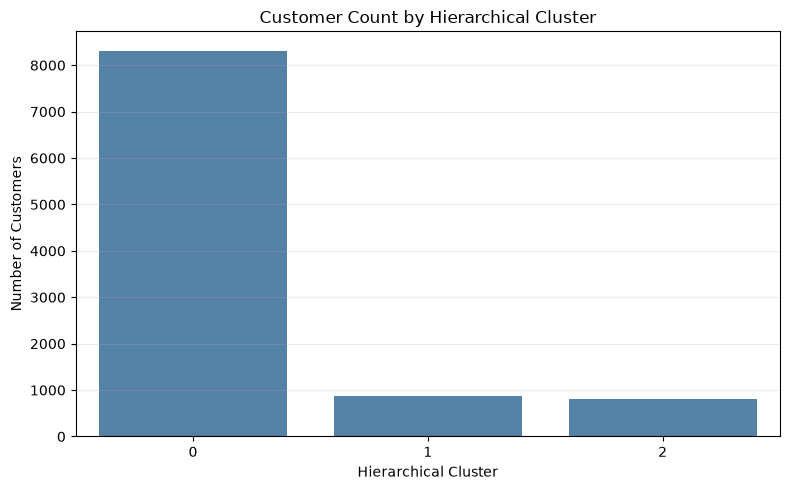

In [66]:
# Cluster sizes
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x='Hierarchical_Cluster',
    order=sorted(df['Hierarchical_Cluster'].unique()),
    color='steelblue'
 )
plt.xlabel('Hierarchical Cluster')
plt.ylabel('Number of Customers')
plt.title('Customer Count by Hierarchical Cluster')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

In [67]:
# 7. Categorical feature breakdown by hierarchical cluster
categorical_profile_columns = [
    col for col in ['Education_Level', 'Marital_Status',
                    'Membership_Tier', 'Device_Type']
    if col in df.columns
 ]

for feature in categorical_profile_columns:
    print(f"\n--- {feature} distribution by hierarchical cluster (%) ---")
    display(
        pd.crosstab(
            df['Hierarchical_Cluster'],
            df[feature],
            normalize='index'
        ).mul(100).round(2)
    )


--- Education_Level distribution by hierarchical cluster (%) ---


Education_Level,Basic,Graduation,Master,PhD
Hierarchical_Cluster,,,,
0,21.29,55.09,22.16,1.46
1,4.01,1.15,0.23,94.62
2,21.06,53.69,22.29,2.96



--- Marital_Status distribution by hierarchical cluster (%) ---


Marital_Status,Divorced,Married,Single,Together,Widow
Hierarchical_Cluster,,,,,
0,20.55,19.69,19.59,19.28,20.89
1,20.39,17.98,20.05,19.70,21.88
2,21.43,18.84,21.18,19.95,18.60



--- Membership_Tier distribution by hierarchical cluster (%) ---


Membership_Tier,Basic,Gold,Platinum,Silver
Hierarchical_Cluster,,,,
0,39.92,20.17,10.43,29.49
1,41.92,19.59,7.79,30.70
2,39.16,19.46,9.61,31.77



--- Device_Type distribution by hierarchical cluster (%) ---


Device_Type,Desktop,Mobile,Tablet
Hierarchical_Cluster,,,
0,44.13,54.25,1.62
1,45.82,46.05,8.13
2,2.71,1.60,95.69


In [68]:
# 8. Final hierarchical summary
hierarchical_summary = df.groupby('Hierarchical_Cluster').agg(
    Customer_Count=('Hierarchical_Cluster', 'size'),
    Avg_Income=('Annual_Income', 'mean'),
    Avg_Spending=('Total_Amount_Spent', 'mean'),
    Avg_Age=('Customer_Age', 'mean'),
    Avg_Recency=('Last_Purchase_Recency', 'mean')
 ).round(2)

hierarchical_summary['Percentage'] = (
    hierarchical_summary['Customer_Count'] / len(df) * 100
 ).round(2)

display(hierarchical_summary)

# Interpretation: higher silhouette scores generally mean better-separated clusters;
# use the dendrogram and business profiles together when evaluating the segments.

,Customer_Count,Avg_Income,Avg_Spending,Avg_Age,Avg_Recency,Percentage
Hierarchical_Cluster,,,,,,
0,8315,50099.33,1450.61,54.10,49.69,83.15
1,873,49625.61,1446.70,54.45,47.64,8.73
2,812,48840.71,1419.92,54.96,50.72,8.12


## DBSCAN

DBSCAN groups customers by density and labels isolated records as noise (`-1`). The `eps` threshold is informed by the k-distance plot and a small candidate sweep; it may need retuning if the scaled features or dataset change.

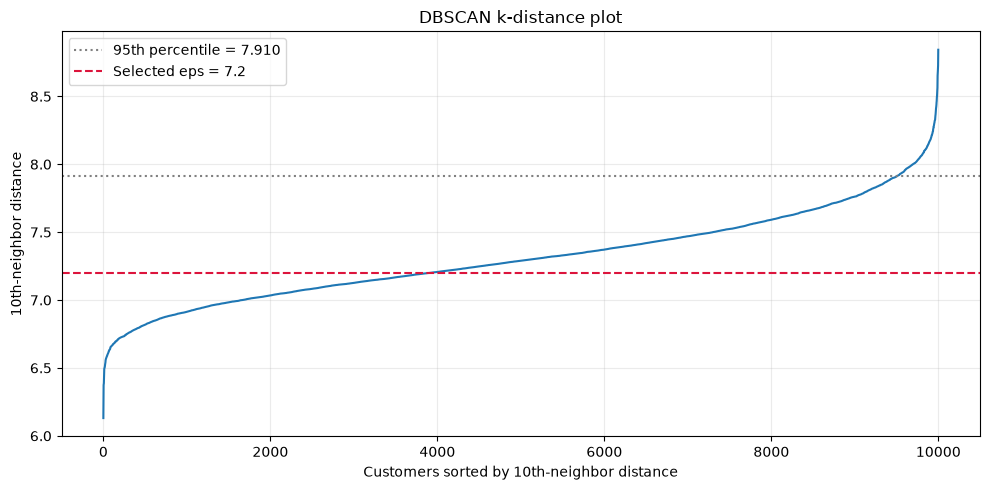

eps=6.80: 18 clusters, 71.38% noise
eps=7.00: 6 clusters, 40.02% noise
eps=7.20: 2 clusters, 17.66% noise
eps=7.40: 1 clusters, 6.08% noise
eps=7.60: 1 clusters, 1.78% noise
eps=7.80: 1 clusters, 0.48% noise
eps=7.91: 1 clusters, 0.25% noise
Selected eps: 7.20; min_samples: 10
Cluster labels (-1 indicates noise):
-1    1766
 0    8226
 1       8
Name: count, dtype: int64


In [71]:
# 9. DBSCAN: use the k-distance curve and check nearby eps values
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

min_samples = 10
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors.fit(X_scaled)
neighbor_distances, _ = neighbors.kneighbors(X_scaled)
k_distances = np.sort(neighbor_distances[:, -1])
eps_reference = float(np.quantile(k_distances, 0.95))

plt.figure(figsize=(10, 5))
plt.plot(k_distances)
plt.axhline(
    eps_reference, color='gray', linestyle=':',
    label=f'95th percentile = {eps_reference:.3f}'
 )
plt.axhline(7.2, color='crimson', linestyle='--', label='Selected eps = 7.2')
plt.xlabel('Customers sorted by 10th-neighbor distance')
plt.ylabel('10th-neighbor distance')
plt.title('DBSCAN k-distance plot')
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Compare nearby thresholds; 7.2 balances cluster separation and noise here.
eps_candidates = [6.8, 7.0, 7.2, 7.4, 7.6, 7.8, eps_reference]
for candidate_eps in eps_candidates:
    candidate_labels = DBSCAN(
        eps=candidate_eps, min_samples=min_samples
    ).fit_predict(X_scaled)
    candidate_clusters = len(set(candidate_labels) - {-1})
    candidate_noise = (candidate_labels == -1).mean() * 100
    print(
        f'eps={candidate_eps:.2f}: {candidate_clusters} clusters, '
        f'{candidate_noise:.2f}% noise'
    )

eps = 7.2
dbscan_model = DBSCAN(eps=eps, min_samples=min_samples)
dbscan_labels = dbscan_model.fit_predict(X_scaled)
df['DBSCAN_Cluster'] = dbscan_labels

print(f"Selected eps: {eps:.2f}; min_samples: {min_samples}")
print("Cluster labels (-1 indicates noise):")
print(pd.Series(dbscan_labels).value_counts().sort_index())

## 10. DBSCAN Silhouette Score and Percentage

In [72]:
# 10. DBSCAN silhouette score on non-noise customers and cluster percentages
dbscan_counts = pd.Series(dbscan_labels).value_counts().sort_index()
dbscan_percentages = (dbscan_counts / len(dbscan_labels) * 100).round(2)

dbscan_distribution = pd.DataFrame({
    'Segment': [
        'Noise' if label == -1 else f'Cluster {label}'
        for label in dbscan_counts.index
    ],
    'Customer_Count': dbscan_counts.values,
    'Percentage': dbscan_percentages.values
}, index=dbscan_counts.index)

noise_mask = dbscan_labels != -1
non_noise_labels = dbscan_labels[noise_mask]
non_noise_features = X_scaled.loc[noise_mask] if isinstance(X_scaled, pd.DataFrame) else X_scaled[noise_mask]
n_non_noise_clusters = len(np.unique(non_noise_labels))

if 2 <= n_non_noise_clusters < len(non_noise_labels):
    silhouette_sample_size = min(2000, len(non_noise_labels))
    dbscan_silhouette = silhouette_score(
        non_noise_features,
        non_noise_labels,
        sample_size=silhouette_sample_size,
        random_state=42
    )
    print(
        f"DBSCAN silhouette score (non-noise sample of "
        f"{silhouette_sample_size:,}): {dbscan_silhouette:.4f}"
    )
else:
    dbscan_silhouette = np.nan
    print("DBSCAN silhouette is undefined: non-noise points have fewer than 2 clusters.")

display(dbscan_distribution)

DBSCAN silhouette score (non-noise sample of 2,000): 0.0244


,Segment,Customer_Count,Percentage
-1,Noise,1766,17.66
0,Cluster 0,8226,82.26
1,Cluster 1,8,0.08


## 11. DBSCAN PCA Scatter Graph

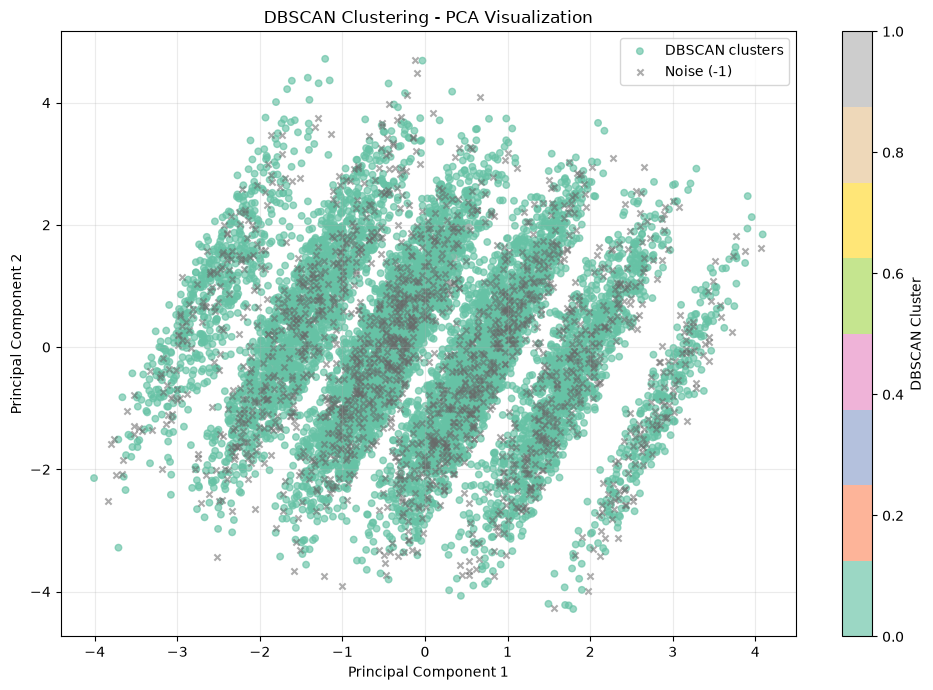

In [73]:
# 11. DBSCAN PCA scatter; mark noise separately from customer clusters
noise_mask = dbscan_labels == -1
cluster_mask = ~noise_mask

plt.figure(figsize=(10, 7))
cluster_scatter = plt.scatter(
    X_pca[cluster_mask, 0],
    X_pca[cluster_mask, 1],
    c=dbscan_labels[cluster_mask],
    cmap='Set2',
    alpha=0.65,
    s=22,
    label='DBSCAN clusters'
 )
noise_scatter = plt.scatter(
    X_pca[noise_mask, 0],
    X_pca[noise_mask, 1],
    c='dimgray',
    marker='x',
    alpha=0.55,
    s=20,
    label='Noise (-1)'
 )
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('DBSCAN Clustering - PCA Visualization')
plt.colorbar(cluster_scatter, label='DBSCAN Cluster')
plt.legend(handles=[cluster_scatter, noise_scatter])
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 12. Compare K-Means vs Hierarchical vs DBSCAN

This section compares the three clustering methods on silhouette quality, cluster counts, cluster balance, and the shared PCA view.


=== Summary Table ===


,Method,Silhouette Score,Clusters Found,Noise %,Largest Cluster %,Smallest Cluster %
0,K-Means,0.0352,3,0.00,54.23,9.83
1,Hierarchical,0.0436,3,0.00,83.15,8.12
2,DBSCAN,0.0244,3,17.66,82.26,0.08



=== Cluster Distribution ===

K-Means:
Cluster
0     9.83
1    35.94
2    54.23
Name: proportion, dtype: float64

Hierarchical:
Hierarchical_Cluster
0    83.15
1     8.73
2     8.12
Name: proportion, dtype: float64

DBSCAN:
DBSCAN_Cluster
-1    17.66
 0    82.26
 1     0.08
Name: proportion, dtype: float64

Best-performing method by silhouette score: Hierarchical (0.0436)
Interpretation: the method with the highest silhouette score is best separated, while DBSCAN adds value by identifying noise and density-based clusters.


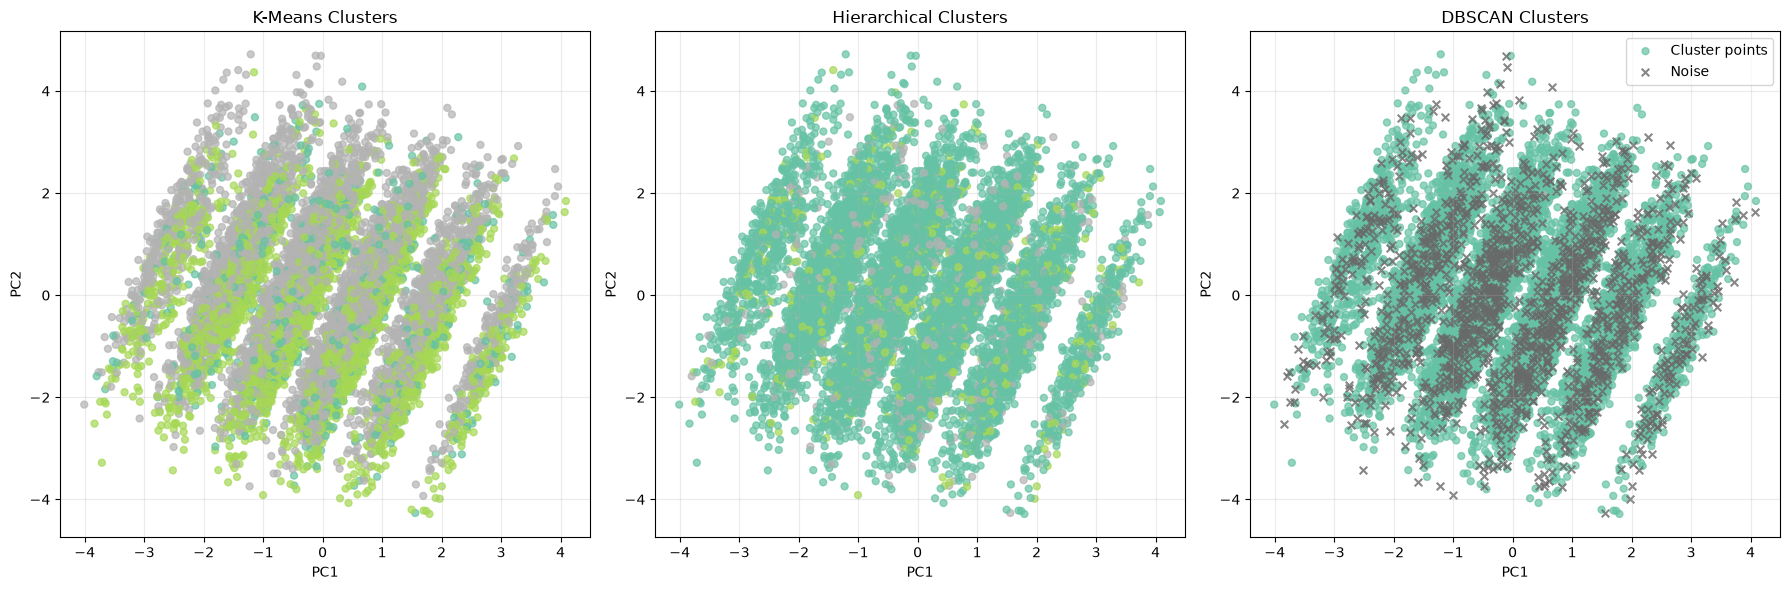

In [73]:
# 12. Compare K-Means vs Hierarchical vs DBSCAN
# Safe access to the labels and metrics created in the earlier sections.

if 'kmeans_silhouette' not in globals():
    kmeans_silhouette = silhouette_score(X_scaled, df['Cluster']) if 'Cluster' in df.columns else np.nan

if 'hierarchical_silhouette' not in globals():
    hierarchical_silhouette = silhouette_score(X_hier, df['Hierarchical_Cluster']) if 'Hierarchical_Cluster' in df.columns else np.nan

if 'dbscan_silhouette' not in globals():
    dbscan_silhouette = np.nan
    noise_mask = df['DBSCAN_Cluster'] != -1 if 'DBSCAN_Cluster' in df.columns else pd.Series([False] * len(df))
    if noise_mask.any():
        non_noise_labels = df.loc[noise_mask, 'DBSCAN_Cluster']
        non_noise_features = X_scaled.loc[noise_mask] if isinstance(X_scaled, pd.DataFrame) else X_scaled[noise_mask]
        if len(np.unique(non_noise_labels)) >= 2 and len(non_noise_labels) > 2:
            dbscan_silhouette = silhouette_score(non_noise_features, non_noise_labels)

method_names = ['K-Means', 'Hierarchical', 'DBSCAN']
method_labels = {
    'K-Means': df['Cluster'] if 'Cluster' in df.columns else pd.Series(np.zeros(len(df), dtype=int)),
    'Hierarchical': df['Hierarchical_Cluster'] if 'Hierarchical_Cluster' in df.columns else pd.Series(np.zeros(len(df), dtype=int)),
    'DBSCAN': df['DBSCAN_Cluster'] if 'DBSCAN_Cluster' in df.columns else pd.Series(np.zeros(len(df), dtype=int)),
}
method_silhouette = {
    'K-Means': kmeans_silhouette,
    'Hierarchical': hierarchical_silhouette,
    'DBSCAN': dbscan_silhouette,
}

comparison_rows = []
for method in method_names:
    labels = method_labels[method].astype(int)
    counts = pd.Series(labels).value_counts().sort_index()
    percentages = (counts / len(labels) * 100).round(2)
    percentage_str = '; '.join([f'{label}: {val:.2f}%' for label, val in percentages.items()])
    comparison_rows.append({
        'Method': method,
        'Silhouette Score': round(method_silhouette[method], 4) if pd.notna(method_silhouette[method]) else np.nan,
        'Clusters Found': len(counts),
        'Noise %': (labels.eq(-1).mean() * 100).round(2) if (-1 in counts.index) else 0.0,
        'Largest Cluster %': round(percentages.max(), 2) if len(percentages) else 0.0,
        'Smallest Cluster %': round(percentages.min(), 2) if len(percentages) else 0.0,
        'Cluster Distribution': percentage_str,
    })

comparison_df = pd.DataFrame(comparison_rows)
print('=== Summary Table ===')
display(comparison_df[['Method', 'Silhouette Score', 'Clusters Found', 'Noise %', 'Largest Cluster %', 'Smallest Cluster %']])
print('\n=== Cluster Distribution ===')
for method in method_names:
    print(f'\n{method}:')
    print(pd.Series(method_labels[method].value_counts(normalize=True) * 100).round(2).sort_index())

best_method = comparison_df.sort_values('Silhouette Score', ascending=False).iloc[0]
print(f"\nBest-performing method by silhouette score: {best_method['Method']} ({best_method['Silhouette Score']:.4f})")
print('Interpretation: the method with the highest silhouette score is best separated, while DBSCAN adds value by identifying noise and density-based clusters.')

# Shared PCA view for side-by-side comparison
if 'X_pca' not in globals():
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, method in zip(axes, method_names):
    labels = method_labels[method].to_numpy() if hasattr(method_labels[method], 'to_numpy') else np.asarray(method_labels[method])
    unique_labels = np.unique(labels)
    if method == 'DBSCAN':
        noise_mask = labels == -1
        cluster_mask = ~noise_mask
        if np.any(cluster_mask):
            sc = ax.scatter(X_pca[cluster_mask, 0], X_pca[cluster_mask, 1], c=labels[cluster_mask], cmap='Set2', alpha=0.7, s=25, label='Cluster points')
            ax.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1], c='dimgray', marker='x', alpha=0.8, s=30, label='Noise')
        else:
            sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='Set2', alpha=0.7, s=25)
    else:
        sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='Set2', alpha=0.7, s=25)
    ax.set_title(f'{method} Clusters')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.grid(alpha=0.25)
    if method == 'DBSCAN':
        ax.legend()

plt.tight_layout()
plt.show()
